### 1.1 - Data Understanding

Let's import data

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
    
from imports import *

pd.set_option('display.max_columns', None)

tracks = pd.read_csv("dataset/tracks.csv",  sep=",")
artists = pd.read_csv("dataset/artists.csv", sep=";")
clust_cols

['bpm',
 'centroid',
 'rolloff',
 'flux',
 'zcr',
 'flatness',
 'spectral_complexity',
 'pitch',
 'loudness',
 'wps',
 'lexical_density',
 'avg_token_per_clause',
 'tokens_per_sent',
 'swear_density_IT']

In [2]:
def plot_xy(df, col1, col2):
    x = df[col1]
    y = df[col2]
    plt.figure(figsize=(8,5))
    plt.scatter(x, y)
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.grid(True)
    plt.show()

def plot_hist(df, col, bins='fd'):
    plt.hist(df[col], bins, edgecolor='black')  
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

def calc_pearson(df, col1, col2):
    x = df[col1]
    y = df[col2]
    mask = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)
    x_clean, y_clean = x[mask], y[mask]

    r, p = stats.pearsonr(x_clean, y_clean)
    return [r, p]

In [3]:
display(tracks)

,id,id_artist,name_artist,full_title,title,featured_artists,primary_artist,language,album,stats_pageviews,swear_IT,swear_EN,swear_IT_words,swear_EN_words,year,month,day,n_sentences,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,rolloff,flux,rms,zcr,flatness,spectral_complexity,pitch,loudness,album_name,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,album_image,id_album,lyrics,modified_popularity
0,TR934808,ART04205421,Rosa Chemical,​polka 2 :-/ by Rosa Chemical (Ft. Ernia & Guè),​polka 2 :-/,"Ernia, Guè",Rosa Chemical,pl,FOREVER AND EVER,196033.0,13,6,"['cazzo', 'cesso', 'coglioni', 'figa', 'merda'...","['bitch', 'fuck', 'porno', 'pussy']",2021.0,4.0,2.0,102.0,911.0,8.931373,4.170455,0.575284,8.133929,135.32,0.1858,2895.7767,1.4499,0.1786,0.1046,0.8202,25.7148,2311.1779,17.8675,FOREVER AND EVER,2021-04-09,album,1.0,3.0,207761.0,True,46.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Oplà, ah\nBdope, chiama due b—\n\nMi candidere...",False
1,TR760029,ART04205421,Rosa Chemical,POLKA by Rosa Chemical (Ft. Thelonious B.),POLKA,Thelonious B.,Rosa Chemical,en,FOREVER AND EVER,164450.0,9,12,"['cazzo', 'culo', 'frocio', 'puttana', 'sega',...","['escort', 'negro', 'sex', 'sexy', 'shit']",2020.0,3.0,6.0,56.0,675.0,12.053571,4.280851,0.648936,12.500000,129.37,0.2071,3378.4605,1.3533,0.2020,0.1175,0.6739,29.1089,1892.1924,21.4595,FOREVER AND EVER,2021-04-09,album,1.0,3.0,207761.0,True,46.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Greg Willen, non dormire\n(Brr-poh)\n\nT-T-Tro...",False
2,TR916821,ART04205421,Rosa Chemical,​britney ;-) by Rosa Chemical (Ft. MamboLosco ...,​britney ;-),"MamboLosco, RADICAL",Rosa Chemical,en,FOREVER AND EVER,58313.0,16,12,"['bastardo', 'cazzo', 'culo', 'merda', 'troia']","['bastardo', 'bitch', 'bitches', 'cock', 'fuck']",2021.0,2.0,19.0,88.0,758.0,8.613636,4.075251,0.556856,8.422222,133.68,0.1833,2037.4847,1.3822,0.2552,0.0800,0.7842,26.9762,2484.3503,29.4590,FOREVER AND EVER,2021-04-09,album,1.0,1.0,193544.0,True,39.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Mothz\nYeah, yeah, yeah-yeah\nBdope, chiama du...",False
3,TR480968,ART04205421,Rosa Chemical,CEO by Rosa Chemical (Ft. Taxi B),CEO,Taxi B,Rosa Chemical,it,OKAY OKAY !! - EP,39890.0,8,3,"['cazzo', 'culo', 'fottere', 'merda', 'pompino...","['fuck', 'porno', 'shit']",2019.0,3.0,8.0,37.0,382.0,10.324324,4.023881,0.534328,6.701754,162.22,0.1048,1156.3781,1.5499,0.1971,0.0436,0.8764,14.2956,2984.6109,20.5067,OKAY OKAY 2,2025-05-16,single,1.0,2.0,169000.0,True,47.0,https://i.scdn.co/image/ab67616d0000b27367c03d...,ALB730959,Designer sui vestiti penso di essere un outlet...,False
4,TR585039,ART04205421,Rosa Chemical,LONDRA by Rosa Chemical (Ft. Rkomi),LONDRA,Rkomi,Rosa Chemical,en,FOREVER AND EVER,35432.0,1,0,['cazzo'],[],2020.0,5.0,29.0,48.0,429.0,8.937500,3.922857,0.491429,8.411765,105.87,0.1421,1693.4542,1.0886,0.2369,0.0695,0.8571,36.6951,1572.0499,25.3407,FOREVER,2020-05-28,album,1.0,8.0,194779.0,True,41.0,https://i.scdn.co/image/ab67616d0000b273fcdb60...,ALB436151,"Bdope (Yeah)\n\nVuole solo me, non fare la gel...",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11161,TR434449,ART02733420,Marracash,Badabum Cha Cha - Gabri Ponte & Paki Rmx (Radi...,Badabum Cha Cha - Gabri Ponte & Paki Rmx (Radi...,NaN,Marracash,it,Badabum Cha Cha (The Remixes),NaN,0,0,[],[],NaN,NaN,NaN,75.0,624.0,8.320000,3.907251,0.521079,6.240000,123.78,0.1092,1140.5174,1.4162,0.2364,0.0497,0.9118,20.9760,3067.5304,26.3440,Che Ne Sanno I 2000 (feat. Danti),2016-07-01,single,1.0,1.0,234374.0,False,57.0,https://i.scdn.co/image/ab67616d0000b2733a7b5b...,ALB248347,"Qui non va, ma questo badabum cha cha\nTira fo...",False
11162,TR826351,ART02733420,Marracash,Senza Un Posto Nel Mondo - Alternative Version...,Senza Un Po

In [4]:
display(artists)

,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,active_end,province,region,country,latitude,longitude
0,ART82291002,99 posse,M,NaN,NaN,NaN,gruppo musicale italiano,1991-01-01,NaN,NaN,NaN,NaN,NaN,NaN
1,ART53496045,achille lauro,M,1990-07-11,Verona,Italia,cantautore e rapper italiano (1990-),2012-01-01,NaN,Verona,Veneto,Italia,45.442498,10.985738
2,ART18853907,alfa,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ART64265460,anna pepe,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ART75741740,articolo 31,M,NaN,NaN,NaN,gruppo musicale hip hop italiano,1990-01-01,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,ART98118784,tormento,M,1975-09-06,Reggio Calabria,Italia,"rapper, cantautore e beatmaker italiano (1975-)",NaN,NaN,Reggio Calabria,Calabria,Italia,38.103539,15.639756
100,ART15560128,vacca,M,1979-10-21,Cagliari,Italia,rapper italiano,2001-01-01,NaN,Cagliari,Sardegna,Italia,39.217199,9.113311
101,ART57587384,willie peyote,M,1985-08-28,Torino,Italia,rapper e cantautore italiano (1985-),2004-01-01,NaN,Torino,Piemonte,Italia,45.067755,7.682489
102,ART71515715,yeиdry,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data cleaning

### Invalid data

In [5]:
tracks.dtypes

id                       object
id_artist                object
name_artist              object
full_title               object
title                    object
featured_artists         object
primary_artist           object
language                 object
album                    object
stats_pageviews         float64
swear_IT                  int64
swear_EN                  int64
swear_IT_words           object
swear_EN_words           object
year                     object
month                   float64
day                     float64
n_sentences             float64
n_tokens                float64
tokens_per_sent         float64
char_per_tok            float64
lexical_density         float64
avg_token_per_clause    float64
bpm                     float64
centroid                float64
rolloff                 float64
flux                    float64
rms                     float64
zcr                     float64
flatness                float64
spectral_complexity     float64
pitch   

We must check for "year", "popularity", "explicit" (they don't match the expected types) (and also correct "album_release_date" to a date)

#### Album release date

In [6]:
tracks['album_release_date'] = pd.to_datetime(tracks['album_release_date'], errors='coerce')

#### Year and Popularity

In [7]:
tracks["year"] = pd.to_numeric(tracks["year"], errors="coerce")
tracks["popularity"] = pd.to_numeric(tracks["popularity"], errors="coerce")

#### Explicit

In [8]:
tracks[ (tracks["explicit"] != False) & (tracks["explicit"] != True) ]["explicit"]

1932    NaN
2304    NaN
3286    NaN
3667    NaN
3668    NaN
       ... 
3737    NaN
3738    NaN
3739    NaN
6390    NaN
9261    NaN
Name: explicit, Length: 78, dtype: object

In [9]:
t1 = tracks[(tracks["explicit"] == True) & (tracks["swear_IT"] + tracks["swear_EN"] == 0)]
len(t1)

1202

In [10]:
t2 = tracks[(tracks["explicit"] == False) & (tracks["swear_IT"] + tracks["swear_EN"] > 0)]
len(t2)

3125

`explicit` can be true even if `swear_IT` and `swear_EN` are both 0.

In [11]:
#tracks["explicit"] = (tracks["swear_IT"] + tracks["swear_EN"] > 0)
tracks["explicit"] = tracks["explicit"].fillna(False)

/tmp/ipykernel_18484/3301152960.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tracks["explicit"] = tracks["explicit"].fillna(False)


In [12]:
tracks.dtypes

id                              object
id_artist                       object
name_artist                     object
full_title                      object
title                           object
featured_artists                object
primary_artist                  object
language                        object
album                           object
stats_pageviews                float64
swear_IT                         int64
swear_EN                         int64
swear_IT_words                  object
swear_EN_words                  object
year                           float64
month                          float64
day                            float64
n_sentences                    float64
n_tokens                       float64
tokens_per_sent                float64
char_per_tok                   float64
lexical_density                float64
avg_token_per_clause           float64
bpm                            float64
centroid                       float64
rolloff                  

Now all the dtypes in tracks are corrected.

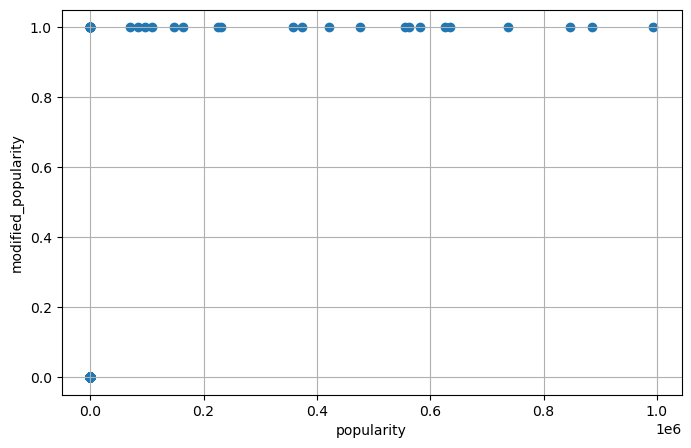

In [13]:
plot_xy(tracks, 'popularity', 'modified_popularity')

When 

In [14]:
tracks.loc[tracks["modified_popularity"] == True, "popularity"] = np.nan

In [15]:
len(tracks[(tracks["popularity"] > 100) | (tracks["popularity"] < 0)])

0

#### Artists

In [16]:
artists.dtypes

id_author        object
name             object
gender           object
birth_date       object
birth_place      object
nationality      object
description      object
active_start     object
active_end      float64
province         object
region           object
country          object
latitude        float64
longitude       float64
dtype: object

In [17]:
artists["active_end"].notna().sum()

np.int64(0)

No active end is known! We can drop that column.

In [18]:
artists = artists.drop(columns=["active_end"])

### Check for duplicated rows

In [19]:
len(tracks[tracks.duplicated(keep=False)])

0

In [20]:
len(artists[artists.duplicated(keep=False)])

0

### Outlier detection

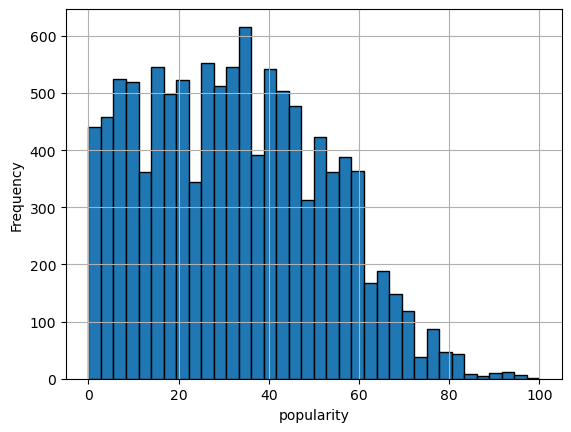

In [21]:
plot_hist(tracks, "popularity")

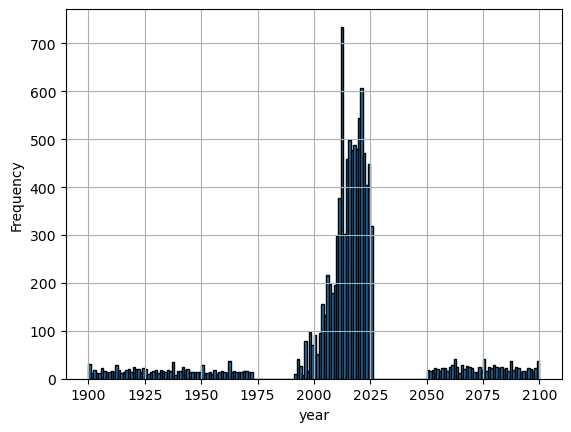

In [22]:
plot_hist(tracks, "year")

In [23]:
tracks[(tracks['year'] < 1975) | (tracks['year'] > 2030)][['full_title', 'year', 'album_release_date']]

,full_title,year,album_release_date
6,LOBBY WAY by Rosa Chemical,2072.0,2020-05-28
7,SLATT by Rosa Chemical (Ft. Dani Faiv),2098.0,2020-05-28
22,Freestyle #redbullnext #essemagazine by Rosa C...,1917.0,2025-05-16
29,Sono Io !! by Rosa Chemical,1920.0,2019-03-08
34,ALIENO by Rosa Chemical,1901.0,2020-01-17
...,...,...,...
11145,Regole by Marracash (Ft. Misa),2085.0,2024-12-13
11147,Esagero (Provino) by Marracash,1947.0,2016-01-22
11156,Chi sale sul ring (Sigla MTV Spit) by Marracash,1947.0,2014-09-23
11158,Crack (Provino) by Marracash,1922.0,2016-01-22


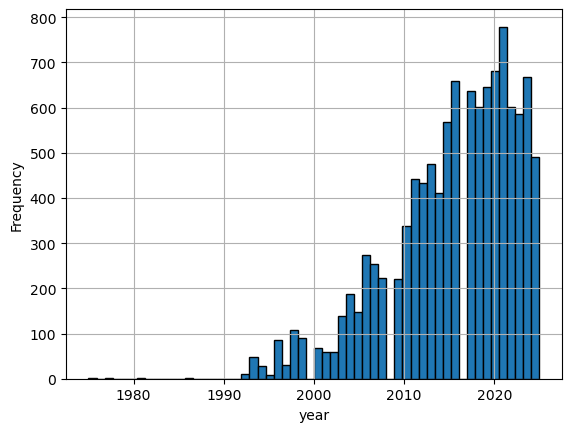

In [24]:
mask = (tracks['year'].isna()) | (tracks['year'] < 1990) | (tracks['year'] > 2030)
tmp = tracks['album_release_date'].dt.year
tracks.loc[mask, 'year'] = tmp.loc[mask]

plot_hist(tracks, 'year')

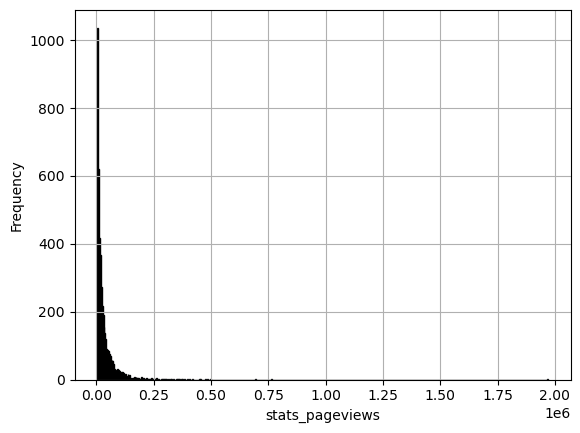

In [25]:
plot_hist(tracks, "stats_pageviews")

It still makes sense to have a song with 2mln views.

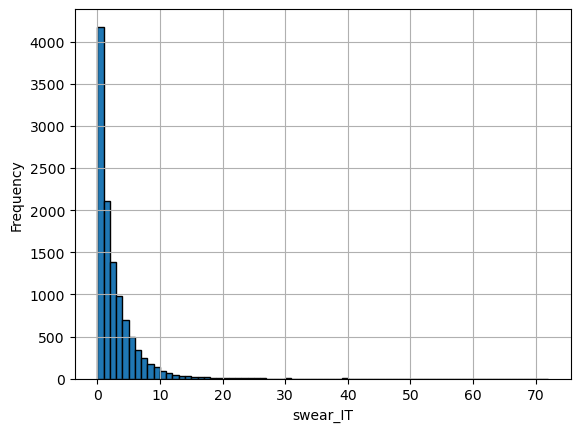

In [26]:
plot_hist(tracks, 'swear_IT')

In [27]:
tracks[tracks['swear_IT'] >40][['full_title', 'swear_IT']]

,full_title,swear_IT
1993,Non fare la puttana by Fabri Fibra,43
2007,Fatti Da Parte by Fabri Fibra,42
2022,CVDM by Fabri Fibra,57
2129,Che Cazzata by Fabri Fibra,50
2462,Ghost Track by Mistaman & DJ Shocca,44
10161,Unpodi by Caneda,72


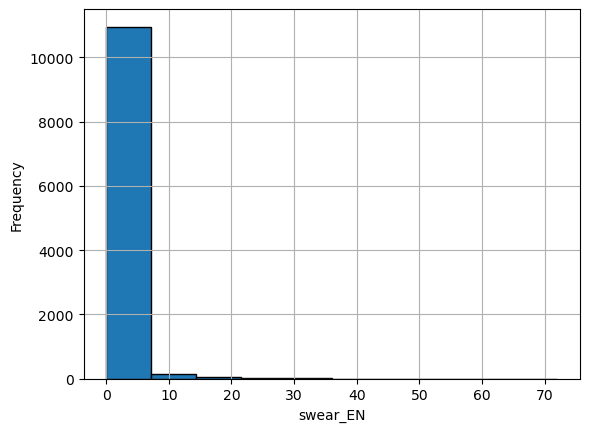

In [28]:
plot_hist(tracks, 'swear_EN', bins=10)

In [29]:
tracks[tracks['swear_EN'] >40][['full_title', 'swear_EN']]

,full_title,swear_EN
41,3SOME by Rosa Chemical (Ft. VillaBanks),64
6539,No Pussy by Ernia,48
9033,Sex On the Beach by Dark Polo Gang,72
10494,Sweet Pussy by Mondo Marcio,55


In [30]:
tracks = tracks[tracks['n_tokens'] > 20]
tracks = tracks[tracks['n_sentences'] > 5]

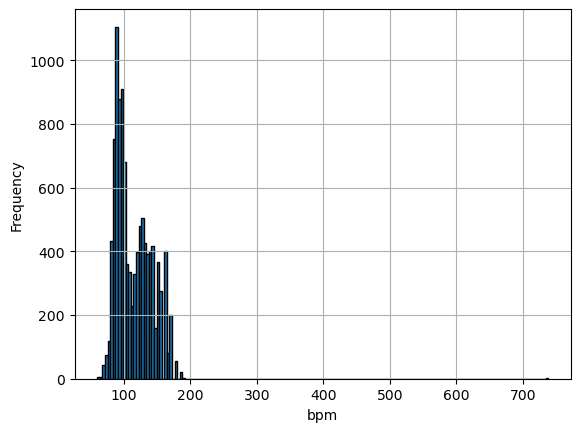

In [31]:
plot_hist(tracks, "bpm")

In [32]:
tracks[tracks["bpm"] > 200][["full_title", "bpm"]]

,full_title,bpm
8317,Madtadone 2015 by MadMan,738.27


Let's remove the clearly wrong value by hands.

In [33]:
tracks = tracks[tracks["bpm"] <= 200]

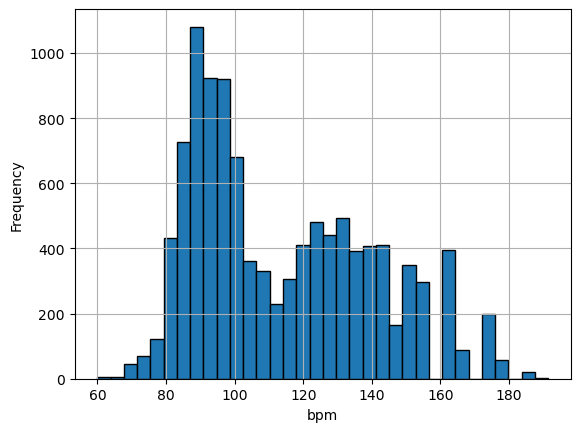

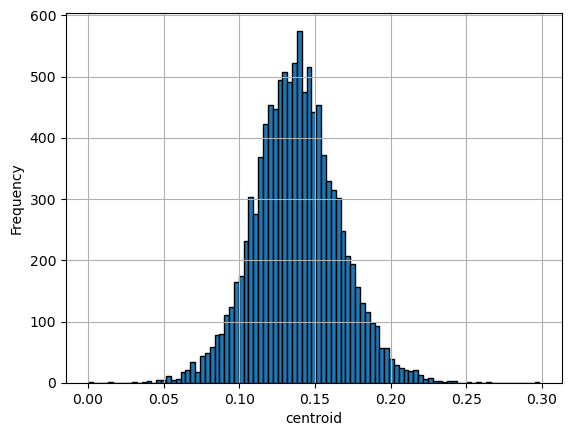

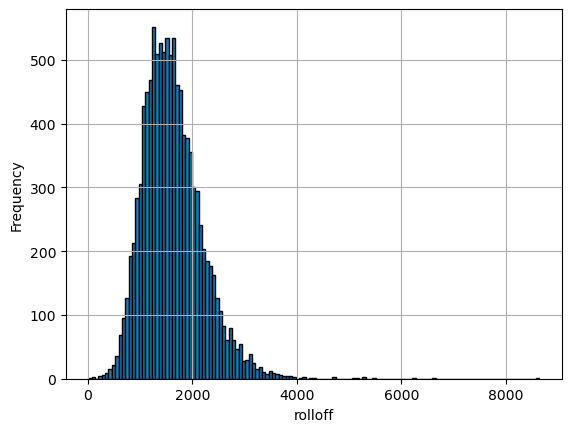

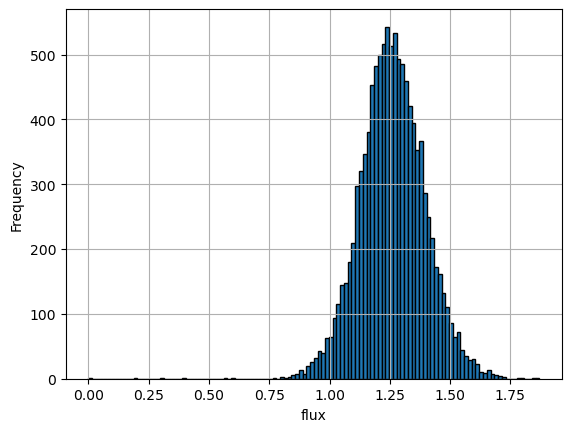

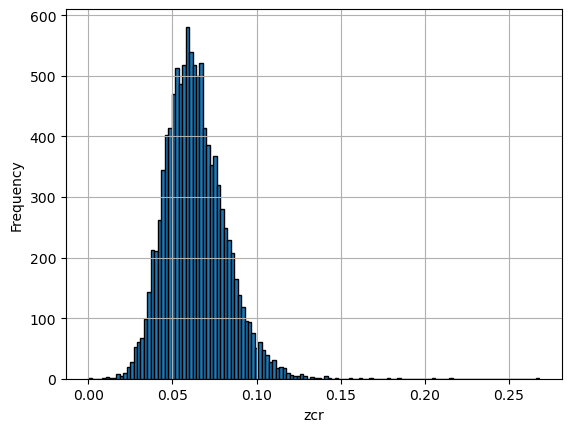

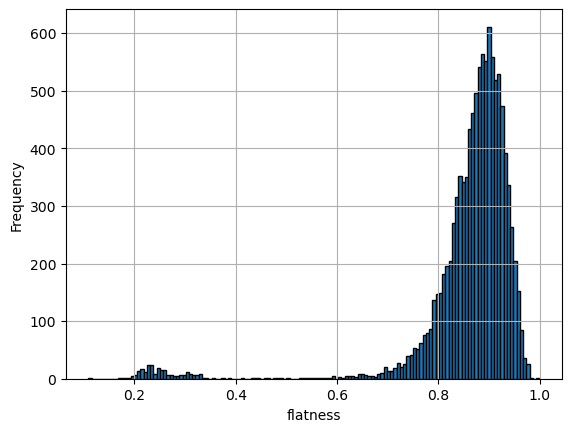

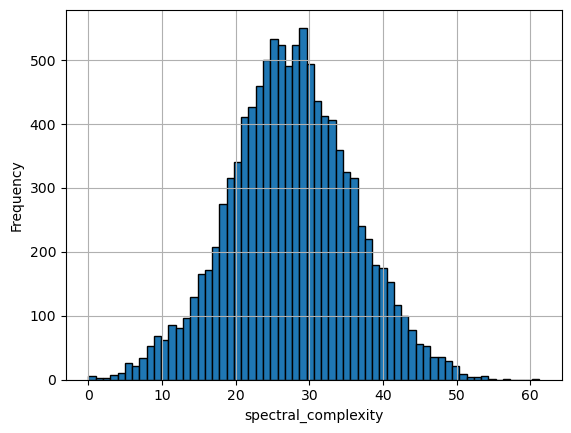

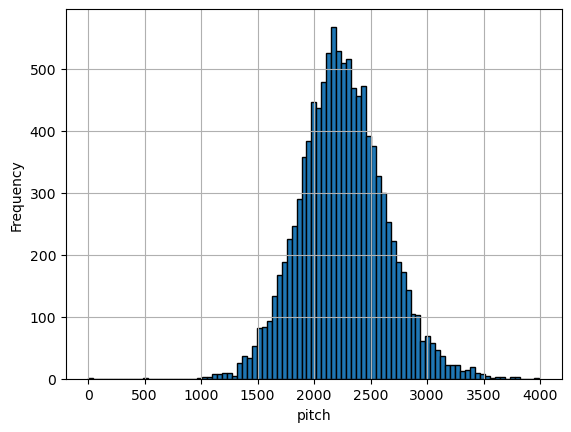

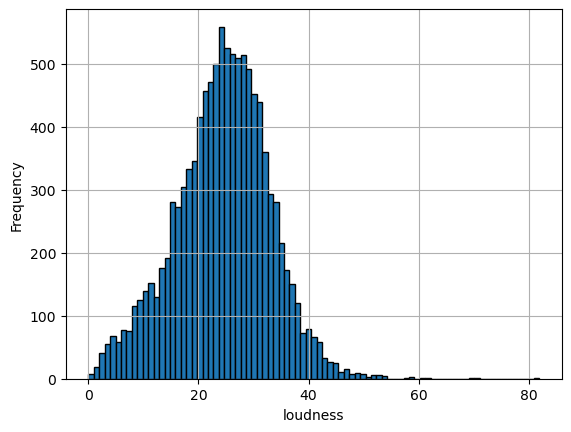

In [34]:
for col in audio_cols:
    plot_hist(tracks, col)

In [35]:
tracks_with_outliers = tracks.copy()

for col in audio_cols:
    print(f"Processing column: {col}, current rows = {len(tracks)}")

    Q1 = tracks[col].quantile(0.15)
    Q3 = tracks[col].quantile(0.85)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    if col == 'year':
        lower = 1980
        upper = 2030

    mask = tracks[col].notna() & ~tracks[col].between(lower, upper)
    n_outliers = mask.sum()
    print(f"Found {n_outliers} outliers")

    # replace outliers with nan
    tracks.loc[mask, col] = np.nan
       
print("Cleaned successfully")
    

Processing column: bpm, current rows = 10847
Found 0 outliers
Processing column: centroid, current rows = 10847
Found 6 outliers
Processing column: rolloff, current rows = 10847
Found 22 outliers
Processing column: flux, current rows = 10847
Found 8 outliers
Processing column: zcr, current rows = 10847
Found 18 outliers
Processing column: flatness, current rows = 10847
Found 298 outliers
Processing column: spectral_complexity, current rows = 10847
Found 0 outliers
Processing column: pitch, current rows = 10847
Found 5 outliers
Processing column: loudness, current rows = 10847
Found 6 outliers
Cleaned successfully


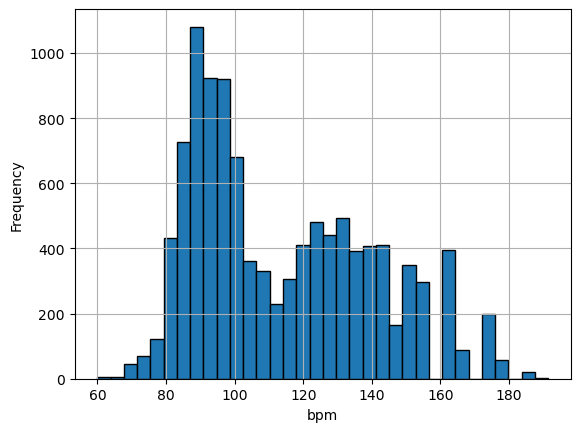

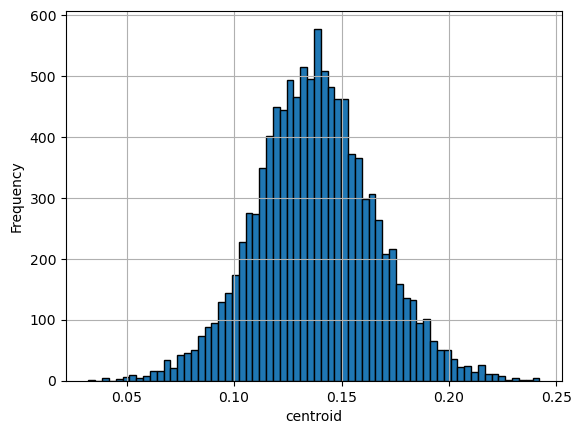

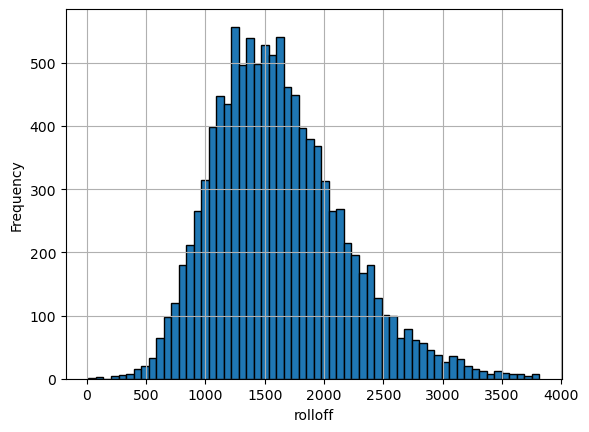

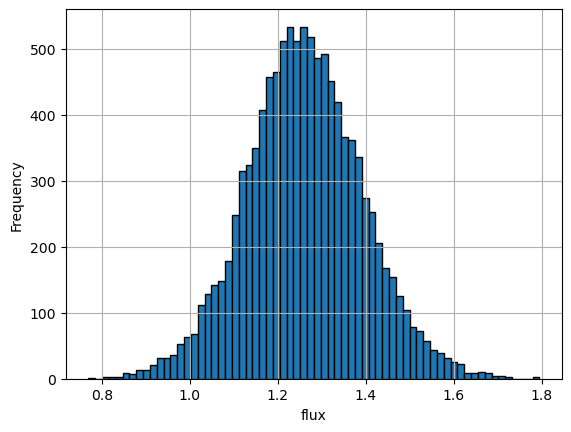

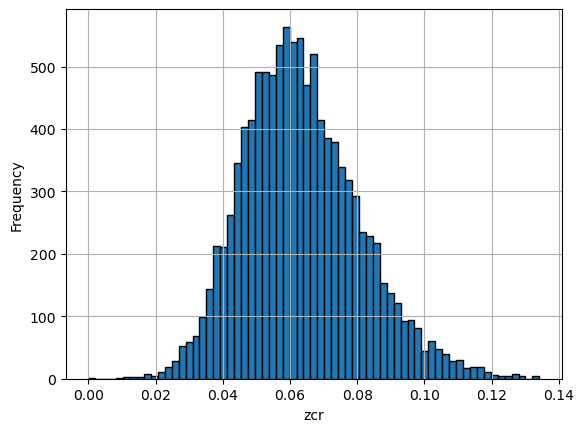

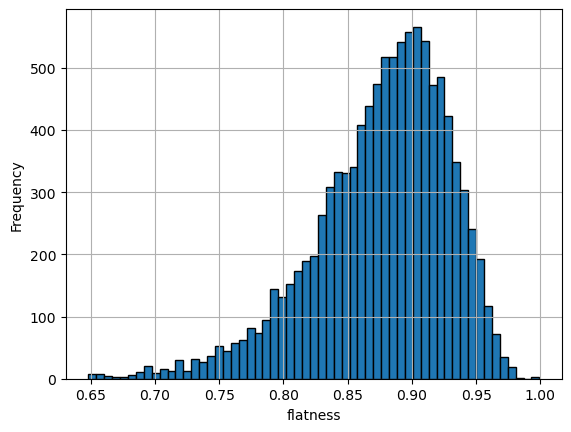

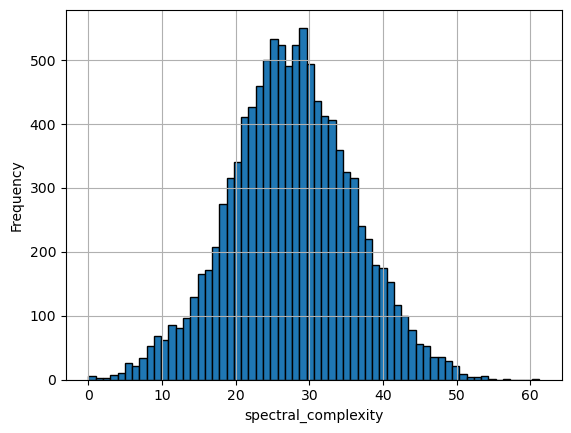

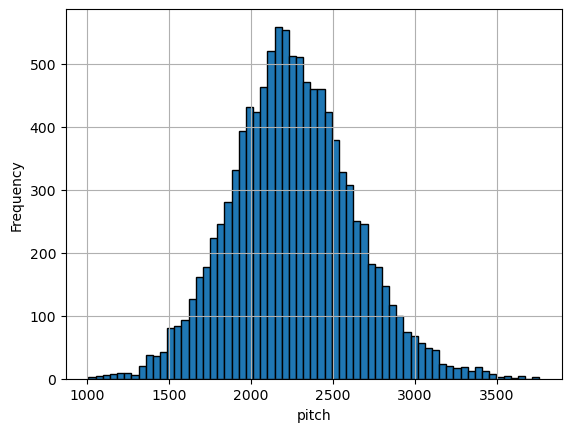

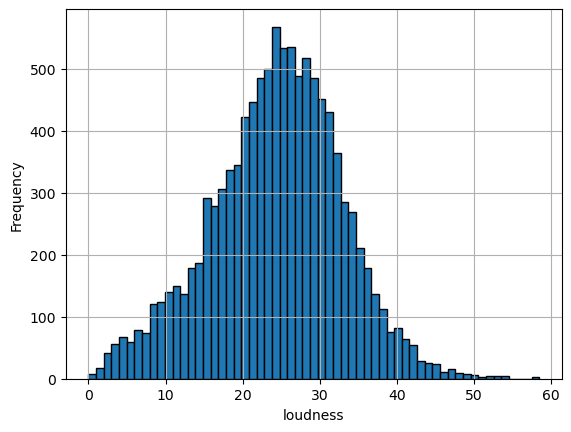

In [36]:
for col in audio_cols:
    plot_hist(tracks, col)

#### Removing some nan

In [37]:
tracks = tracks.dropna(subset=audio_cols)
tracks.isnull().sum()

id                         0
id_artist                  0
name_artist                0
full_title                 0
title                      0
featured_artists        7166
primary_artist             0
language                  73
album                   1407
stats_pageviews         5919
swear_IT                   0
swear_EN                   0
swear_IT_words             0
swear_EN_words             0
year                      73
month                   1014
day                     1122
n_sentences                0
n_tokens                   0
tokens_per_sent            0
char_per_tok               0
lexical_density            0
avg_token_per_clause       0
bpm                        0
centroid                   0
rolloff                    0
flux                       0
rms                        0
zcr                        0
flatness                   0
spectral_complexity        0
pitch                      0
loudness                   0
album_name                 5
album_release_

In [38]:
tracks = tracks.dropna(subset=['year', 'album_name'])

In [39]:
tracks.isnull().sum()

id                         0
id_artist                  0
name_artist                0
full_title                 0
title                      0
featured_artists        7102
primary_artist             0
language                  71
album                   1402
stats_pageviews         5850
swear_IT                   0
swear_EN                   0
swear_IT_words             0
swear_EN_words             0
year                       0
month                    961
day                     1069
n_sentences                0
n_tokens                   0
tokens_per_sent            0
char_per_tok               0
lexical_density            0
avg_token_per_clause       0
bpm                        0
centroid                   0
rolloff                    0
flux                       0
rms                        0
zcr                        0
flatness                   0
spectral_complexity        0
pitch                      0
loudness                   0
album_name                 0
album_release_

### Defining other variables

#### Unix time

In [40]:
tracks = tracks.assign(
    unixtime = pd.to_datetime(dict(year=tracks["year"], month=tracks["month"], day=tracks["day"]), errors="coerce")
)
tracks.sort_values(by="year", ascending=False)

,id,id_artist,name_artist,full_title,title,featured_artists,primary_artist,language,album,stats_pageviews,swear_IT,swear_EN,swear_IT_words,swear_EN_words,year,month,day,n_sentences,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,rolloff,flux,rms,zcr,flatness,spectral_complexity,pitch,loudness,album_name,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,album_image,id_album,lyrics,modified_popularity,unixtime
40,TR885356,ART04205421,Rosa Chemical,0.25X by Rosa Chemical,0.25X,NaN,Rosa Chemical,it,OKAY OKAY 2 - EP,NaN,3,3,"['piscio', 'scopare', 'sega']","['bitch', 'pussy', 'threesome']",2025.0,5.0,16.0,32.0,327.0,10.218750,4.120155,0.569767,11.275862,153.30,0.1814,2669.8838,1.2984,0.3032,0.0957,0.8241,37.8022,2296.2452,36.6221,OKAY OKAY 2,2025-05-16,single,1.0,1.0,107532.0,True,41.0,https://i.scdn.co/image/ab67616d0000b27367c03d...,ALB730959,Pussy creamy sembra un avocado snocciolato (Da...,False,2025-05-16
31,TR127960,ART04205421,Rosa Chemical,ceo 2 by Rosa Chemical (Ft. Macello),ceo 2,Macello,Rosa Chemical,it,OKAY OKAY 2 - EP,NaN,9,7,"['cazzo', 'culo', 'fottuto', 'merda']","['ass', 'bitch', 'fuck', 'porno', 'sex']",2025.0,5.0,16.0,54.0,719.0,13.314815,4.084112,0.553271,10.271429,120.13,0.2109,3582.4288,1.2478,0.2094,0.1194,0.8214,33.7949,1824.7316,22.7303,OKAY OKAY 2,2025-05-16,single,1.0,2.0,169000.0,True,47.0,https://i.scdn.co/image/ab67616d0000b27367c03d...,ALB730959,"lildombaby\n\nPrendo gocce, sono rallentato (W...",False,2025-05-16
5216,TR206792,ART05528539,Luchè,Il mio lato peggiore by Luchè (Ft. Lele Adani),Il mio lato peggiore,Lele Adani,Luchè,it,Il mio lato peggiore,19720.0,4,2,"['cazzo', 'culo']",['bitch'],2025.0,4.0,18.0,70.0,897.0,12.814286,4.071523,0.499338,9.153061,89.93,0.1236,1574.3853,1.2275,0.2789,0.0538,0.9249,32.3797,2181.7683,31.0285,Il mio lato peggiore,2025-05-16,album,1.0,7.0,223834.0,True,79.0,https://i.scdn.co/image/ab67616d0000b2730bd9d3...,ALB473208,Que pongan Voga\n\nAi lati del perizoma ha un ...,False,2025-04-18
6959,TR534899,ART46711784,Frah Quintale,Lampo by Frah Quintale,Lampo,NaN,Frah Quintale,it,NaN,NaN,0,0,[],[],2025.0,6.0,20.0,33.0,193.0,5.848485,4.015873,0.476190,5.361111,119.97,0.0834,1820.2966,0.9039,0.1980,0.0598,0.9692,35.5022,1193.5186,19.1621,Istantanea,2020-04-07,single,1.0,1.0,150857.0,True,31.0,https://i.scdn.co/image/ab67616d0000b2736cfe5c...,ALB346952,\nSei arrivata all'improvviso\nRotto il buio i...,False,2025-06-20
51,TR578432,ART04205421,Rosa Chemical,X&V by Rosa Chemical,X&V,NaN,Rosa Chemical,it,OKAY OKAY 2 - EP,NaN,2,9,"['cazzo', 'culo']","['bitch', 'clit', 'dick', 'pussy', 'sexy']",2025.0,5.0,16.0,43.0,521.0,12.116279,3.590426,0.579787,10.215686,150.10,0.1764,2002.7622,1.2404,0.3399,0.0786,0.8659,40.0712,2042.2873,40.6788,OKAY OKAY 2,2025-05-16,single,1.0,5.0,143389.0,True,34.0,https://i.scdn.co/image/ab67616d0000b27367c03d...,ALB730959,Com'è che faceva quel pezzo?\nVat'la piè 'nta ...,False,2025-05-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7335,TR706801,ART85046033,Gemitaiz,Low budget by Gemitaiz & MadMan (Ft. Coez & Pr...,Low budget,"Primo Brown, Coez",Gemitaiz,it,Haterproof,NaN,3,1,"['coglioni', 'fottuto', 'stronzo']",['negro'],1986.0,10.0,15.0,89.0,825.0,9.269663,4.101717,0.548217,7.568807,95.92,0.1159,1047.7826,1.0880,0.3077,0.0509,0.9693,47.8089,2264.7561,34.6139,Come Dancing with the Kinks (The Best of the K...,1986-06-01,compilation,1.0,2.0,228506.0,False,12.0,https://i.scdn.co/image/ab67616d0000b273ec17a9...,ALB716692,Yes\nE adesso due king più due king fanno quat...,False,1986-10-15
6254,TR379498,ART57587384,Willie Peyote,I (Really Don't) Like by Willie Peyote,I (Really Don’t) Like,NaN,Willie Peyote,it,Quattro San Simoni e un funerale EP,NaN,6,1,"['cazzo', 'coglioni', 'figo', 'stronzo']",['hardcore'],1986.0,4.0,30.0,54.0,457.0,8.462963,4.01

#### Lyrics variables

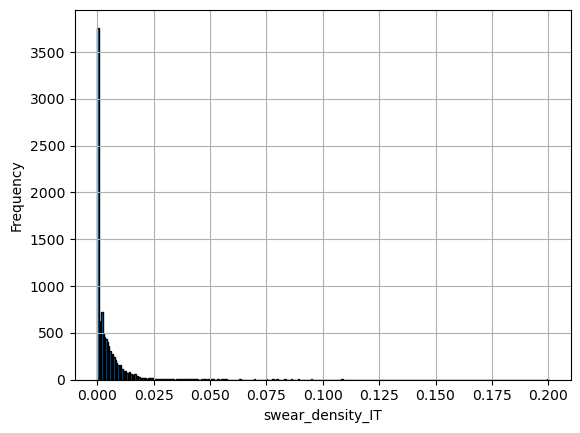

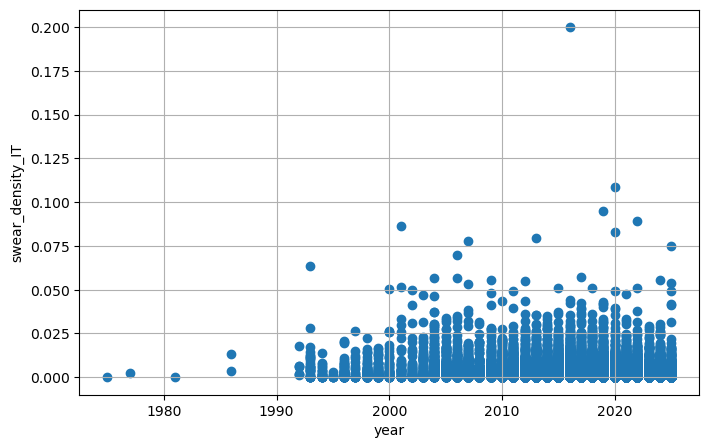

,id,id_artist,name_artist,full_title,title,featured_artists,primary_artist,language,album,stats_pageviews,swear_IT,swear_EN,swear_IT_words,swear_EN_words,year,month,day,n_sentences,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,rolloff,flux,rms,zcr,flatness,spectral_complexity,pitch,loudness,album_name,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,album_image,id_album,lyrics,modified_popularity,unixtime,swear_density_IT
12,TR497808,ART04205421,Rosa Chemical,NUOVI GAY by Rosa Chemical,NUOVI GAY,NaN,Rosa Chemical,it,FOREVER AND EVER,14555.0,36,1,"['cazzo', 'frocio', 'gay', 'puttana']",['bitches'],2020.0,5.0,29.0,57.0,332.0,5.824561,3.785992,0.579767,8.300000,125.06,0.1394,1755.2472,1.4100,0.2754,0.0633,0.8123,26.8521,2877.0575,32.8955,FOREVER,2020-05-28,album,1.0,9.0,210369.0,True,21.0,https://i.scdn.co/image/ab67616d0000b273fcdb60...,ALB436151,"Bdope, chiama due bitches\nLa mia generazione ...",False,2020-05-29,0.108434
1619,TR526693,ART66932389,Piotta,Ridateci la Piotta by Piotta,Ridateci la Piotta,NaN,Piotta,it,Multi Culti,NaN,8,0,"['porca', 'puttana', 'troia']",[],2007.0,NaN,NaN,19.0,103.0,5.421053,4.376344,0.537634,7.923077,107.88,0.1418,1986.4473,1.3637,0.2132,0.0757,0.8350,34.4701,2209.9117,22.5577,Multi Culti,2007-01-26,album,1.0,1.0,67093.0,False,2.0,https://i.scdn.co/image/ab67616d0000b2738f263d...,ALB354874,"Sei una moneta completamente inutile\nUn euro,...",False,NaT,0.077670
2042,TR481276,ART25707984,Fabri Fibra,Brutto Figlio Di by Fabri Fibra,Brutto Figlio Di,NaN,Fabri Fibra,it,Caos,30339.0,40,0,"['cazzo', 'culo', 'figa', 'puttana']",[],2022.0,3.0,18.0,50.0,449.0,8.980000,4.345178,0.581218,12.135135,172.27,0.1616,1338.0550,1.4221,0.3121,0.0614,0.9218,30.8193,2575.2487,36.3991,Caos,2022-03-18,album,1.0,3.0,158786.0,True,39.0,https://i.scdn.co/image/ab67616d0000b273b39f1c...,ALB504788,"Ah\nRitorno sul beat, brutto figlio di puttana...",False,2022-03-18,0.089087
2462,TR571183,ART48537029,Mistaman,Ghost Track by Mistaman & DJ Shocca,Ghost Track,NaN,Mistaman,it,Colpi In Aria,NaN,44,1,"['bernarda', 'cazzo', 'cesso', 'chiavare', 'co...",['nigga'],2001.0,NaN,NaN,77.0,509.0,6.610390,4.255411,0.523810,6.972603,83.48,0.1642,2112.4833,1.3352,0.1672,0.0703,0.8166,22.2821,2565.4836,16.4406,Demon Days,2005-05-23,album,1.0,6.0,222640.0,False,91.0,https://i.scdn.co/image/ab67616d0000b27319d85a...,ALB208414,"Yo yo, puttana\nInfelicity Squad qui, qui\nCon...",False,NaT,0.086444
3149,TR523962,ART87497821,Sfera Ebbasta,#Cheffigo by Sfera Ebbasta (Ft. Ghali),#Cheffigo,Ghali,Sfera Ebbasta,it,Emergenza Mixtape Vol. 1,7250.0,37,2,"['cagna', 'cazzo', 'figo', 'fottuto', 'frocio']",['fuck'],2013.0,9.0,15.0,56.0,465.0,8.303571,3.976190,0.603175,6.283784,95.00,0.1145,1343.7394,1.2342,0.1775,0.0530,0.8656,19.5129,2743.0496,18.0128,SANTANA MONEY GANG,2025-04-10,album,1.0,8.0,232676.0,True,70.0,https://i.scdn.co/image/ab67616d0000b273d6cdd0...,ALB254691,"Ah, Sfera Ebbasta è fresco come l'aria di mont...",False,2013-09-15,0.079570
7437,TR117359,ART09119396,DrefGold,Kzz Mrd by DrefGold,Kzz Mrd,NaN,DrefGold,it,Kanaglia Mixtape,NaN,25,0,"['cagna', 'cazzo', 'fortuna', 'merda', 'sfiga']",[],2020.0,7.0,12.0,51.0,301.0,5.901961,4.270758,0.577617,6.404255,87.81,0.1647,1752.1693,1.3949,0.2124,0.0744,0.8488,25.9855,2423.7423,22.1338,ELO,2020-05-21,album,1.0,2.0,220896.0,True,61.0,https://i.scdn.co/image/ab67616d0000b273297053...,ALB137554,Bella a tutti i regaz là fuori\nNoi ci proviam...,False,2020-07-12,0.083056
9426,TR978319,ART56967402,Samuel Costa,Che palle by Samuel Costa,Che palle,NaN,Samuel Costa,it,Triste,NaN,35,0,"['madonna', 'palle']",[],2019.0,5.0,17.0,57.0,369.0,6.473684,3.884244,0.488746,7.851064,126.01,0.1265,1742.9268,1.5689,0.1739,0.0603,0.7766,15.6631,2916.5122,17.7962,Triste,2019-05-17,album,1.0,1.0,116785.0,True,14.0,https://i.scdn.co/image/ab67616d0000b2736f217d...,ALB150178,Ah\nOkay\nAh-ah\n\nMi si è rotto lo schermo\nS...,False,2019-05-17,0.094851
10161,TR

In [41]:
tracks["swear_density_IT"] = tracks["swear_IT"] / tracks["n_tokens"]

plot_hist(tracks, "swear_density_IT")
plot_xy(tracks, "year", "swear_density_IT")
tracks[tracks["swear_density_IT"]>0.075]

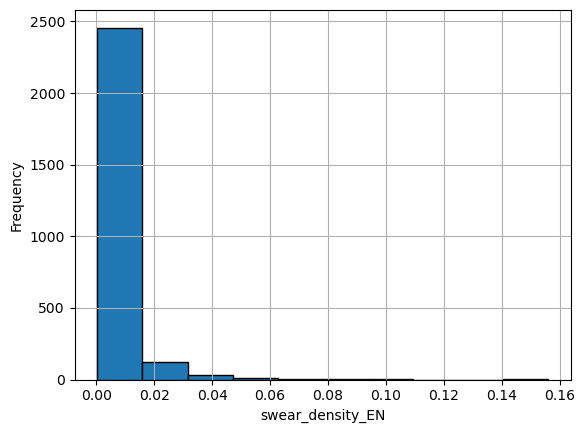

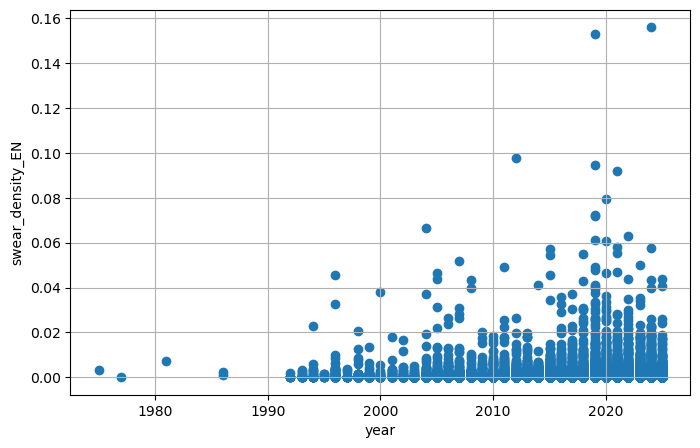

,id,id_artist,name_artist,full_title,title,featured_artists,primary_artist,language,album,stats_pageviews,swear_IT,swear_EN,swear_IT_words,swear_EN_words,year,month,day,n_sentences,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,rolloff,flux,rms,zcr,flatness,spectral_complexity,pitch,loudness,album_name,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,album_image,id_album,lyrics,modified_popularity,unixtime,swear_density_IT,swear_density_EN
41,TR614930,ART04205421,Rosa Chemical,3SOME by Rosa Chemical (Ft. VillaBanks),3SOME,VillaBanks,Rosa Chemical,it,NaN,NaN,1,64,['figa'],['threesome'],2024.0,6.0,21.0,51.0,410.0,8.039216,4.983221,0.570470,15.185185,129.72,0.1840,2515.3547,1.3069,0.2731,0.0994,0.7743,37.2041,2255.9006,30.6359,3SOME (feat. VillaBanks),2024-06-19,single,1.0,1.0,122076.0,True,31.0,https://i.scdn.co/image/ab67616d0000b273871674...,ALB931361,"È Rosa Chemical, ahahah\nVat'la piè 'nta 'l cu...",False,2024-06-21,0.002439,0.156098
4373,TR355590,ART56320683,Bassi Maestro,Intro (Monkee Bizniz Vol. 2) by Bassi Maestro,Intro (Monkee Bizniz Vol. 2),NaN,Bassi Maestro,en,Monkee Bizniz Vol. 2,NaN,0,4,[],"['bitch', 'cock', 'shit']",2012.0,NaN,NaN,11.0,41.0,3.727273,4.102564,0.512821,0.000000,98.79,0.1362,1932.7681,1.3022,0.2350,0.0773,0.8865,34.5277,2037.7258,25.4291,Stanno tutti bene,2012-02-14,album,1.0,9.0,177333.0,True,40.0,https://i.scdn.co/image/ab67616d0000b2739496bd...,ALB932114,Monkee Bizniz Vol. 2\n Busdeez\nYou know my na...,False,NaT,0.000000,0.097561
5084,TR495366,ART43601431,M¥SS KETA,GIOVANNA HARDCORE by M¥SS KETA,GIOVANNA HARDCORE,NaN,M¥SS KETA,it,IL CIELO NON È UN LIMITE - EP,NaN,0,26,[],"['fuck', 'hardcore']",2020.0,8.0,28.0,57.0,327.0,5.736842,4.058824,0.544118,7.785714,125.95,0.1351,1627.6541,1.3545,0.2595,0.0616,0.8668,21.7581,2831.9206,29.6918,IL CIELO NON È UN LIMITE,2020-11-12,album,1.0,2.0,186190.0,True,33.0,https://i.scdn.co/image/ab67616d0000b273b3b082...,ALB629123,(Pronto? Chi sei? Non ti sento)\n(Pronto? Chi ...,False,2020-08-28,0.000000,0.079511
6160,TR742710,ART17812958,J-Ax,Knockout by J-Ax,Knockout,NaN,J-Ax,en,NaN,NaN,0,37,[],"['ass', 'bitch', 'bitches', 'shit']",2021.0,8.0,24.0,49.0,402.0,8.204082,3.867925,0.239892,50.250000,117.49,0.1358,1774.0166,1.0150,0.0460,0.0719,0.7396,9.6619,1619.2223,2.8685,Suddenly in Fashion,2020-06-30,album,1.0,8.0,248816.0,False,0.0,https://i.scdn.co/image/ab67616d0000b2730d02d1...,ALB919848,Got a couple bad bitches and it’s time to win\...,False,2021-08-24,0.000000,0.092040
6539,TR475447,ART76284946,Ernia,No Pussy by Ernia,No Pussy,NaN,Ernia,it,68 (Till The End),49027.0,3,48,"['cazzo', 'sega']",['pussy'],2019.0,9.0,7.0,61.0,507.0,8.311475,3.896635,0.411058,10.787234,120.75,0.1180,1343.1467,1.4675,0.2871,0.0484,0.7888,18.8196,2695.6979,34.1664,68 (Till The End),2019-04-05,album,2.0,5.0,162000.0,False,29.0,https://i.scdn.co/image/ab67616d0000b2734dc927...,ALB374796,"Oh Ernia, non essere così superficiale\nOh\n\n...",False,2019-09-07,0.005917,0.094675
9033,TR747845,ART96068455,Dark Polo Gang,Sex On the Beach by Dark Polo Gang,Sex On the Beach,NaN,Dark Polo Gang,en,Trap Lovers Reloaded,23771.0,0,72,[],"['bitch', 'sex']",2019.0,5.0,17.0,71.0,471.0,6.633803,3.627027,0.516216,17.444444,99.85,0.1727,1755.7951,1.2869,0.3143,0.0740,0.7863,39.4521,2455.2603,36.2659,Trap Lovers (Reloaded),2019-05-24,album,1.0,2.0,166231.0,True,52.0,https://i.scdn.co/image/ab67616d0000b2736f06b1...,ALB219122,"Sex, sex\nSex, sex\nSex, sex\nSex, sex\nSick L...",False,2019-05-17,0.000000,0.152866


In [42]:
tracks["swear_density_EN"] = tracks["swear_EN"] / tracks["n_tokens"]

plot_hist(tracks[tracks["swear_density_EN"]>0], "swear_density_EN", bins=10)
plot_xy(tracks, "year", "swear_density_EN")
tracks[tracks["swear_density_EN"]>0.075]

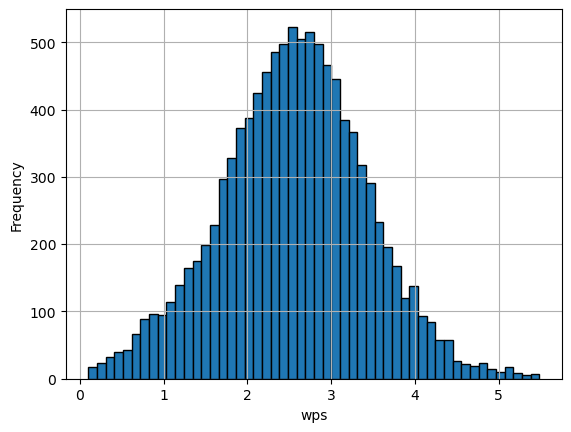

In [43]:
tracks["wps"] = 1000*tracks["n_tokens"]/tracks["duration_ms"]

tracks[(tracks["wps"]>5.5) & (tracks["wps"] < 20)][["full_title", "n_tokens", "duration_ms", "wps"]]
#after having chechked the songs by hand i noticed error in duration and/or n_tokens
# moreover the italian wps record is held by Paolo Bonolis with 332 wpm = 5.5
# i really doubt someone can do something on par with that for multiple minutes
# at the very least, if someone does, it is considerable an outlier
tracks = tracks[tracks['wps'] <= 5.5]

plot_hist(tracks, "wps")

Checking distributions of lyrical variables

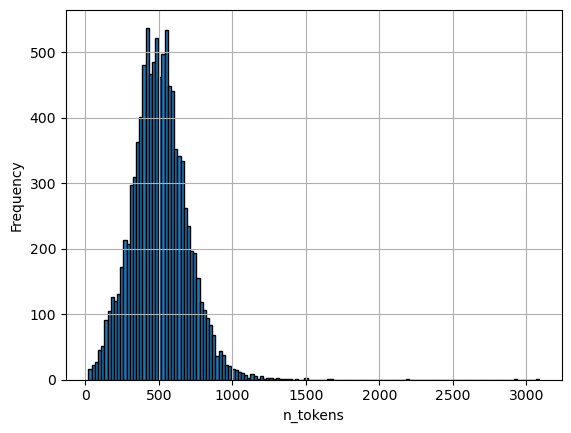

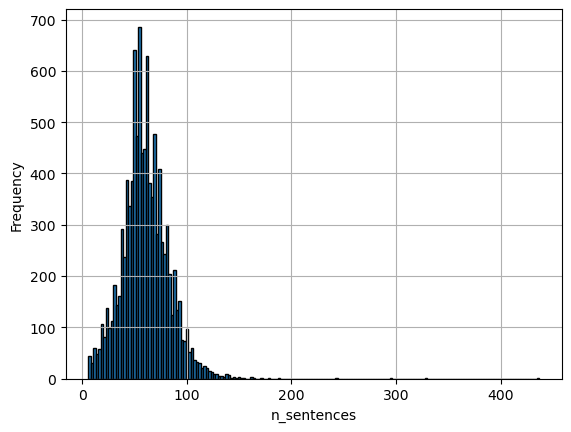

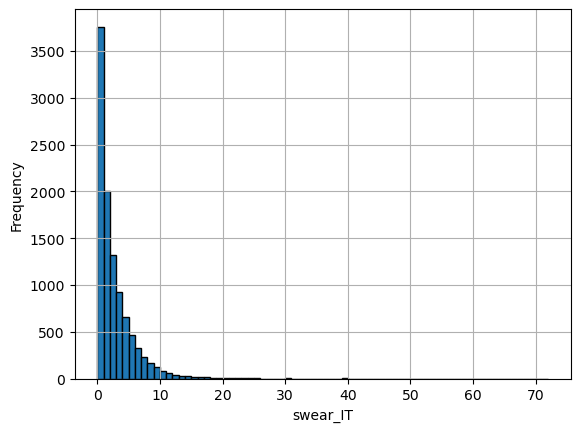

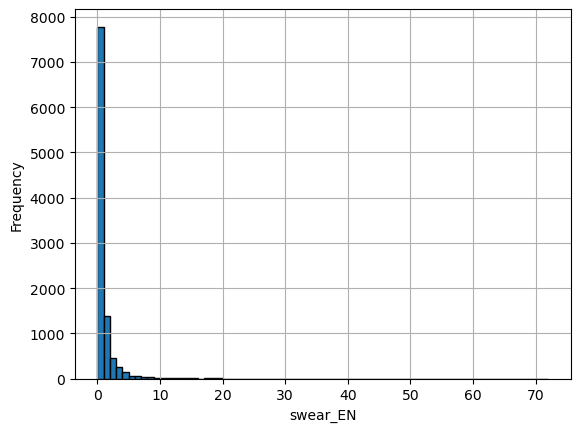

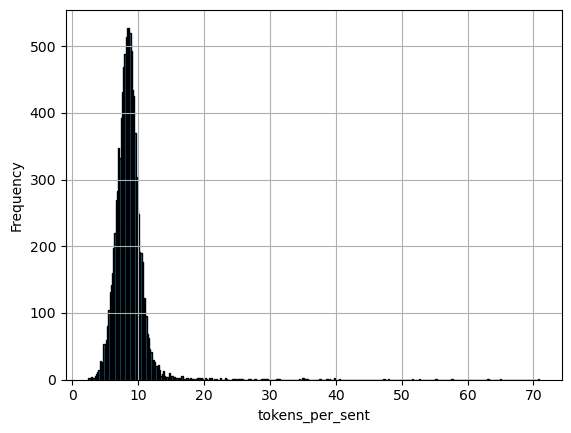

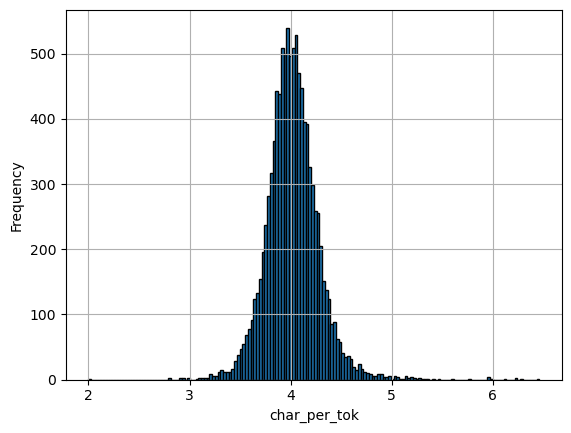

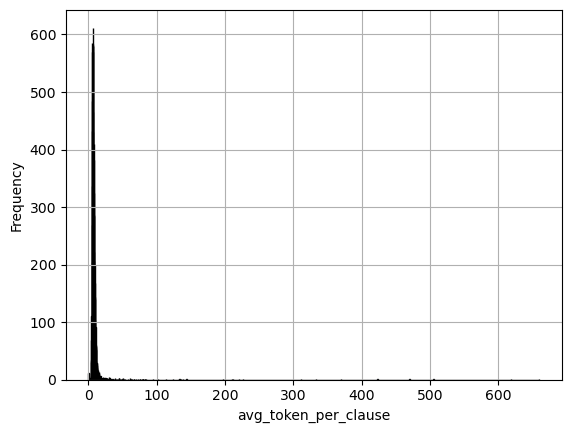

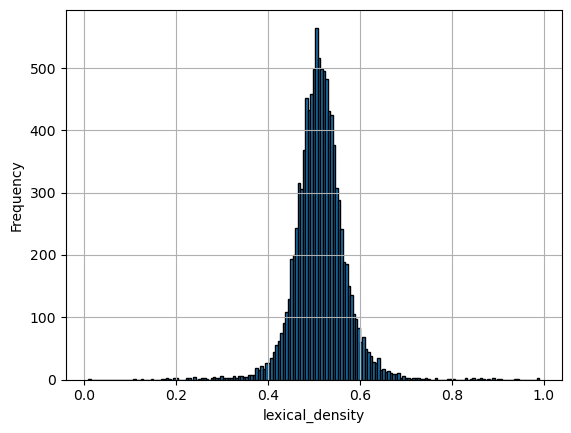

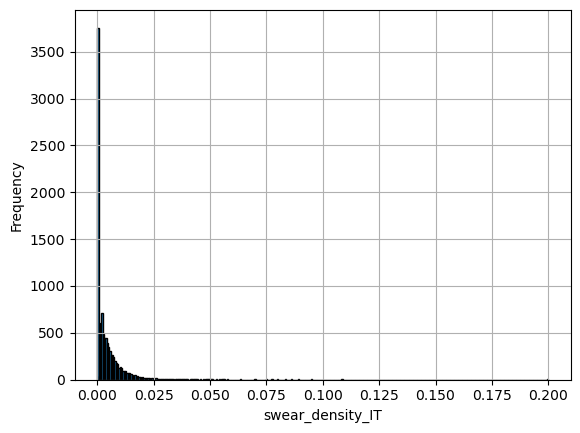

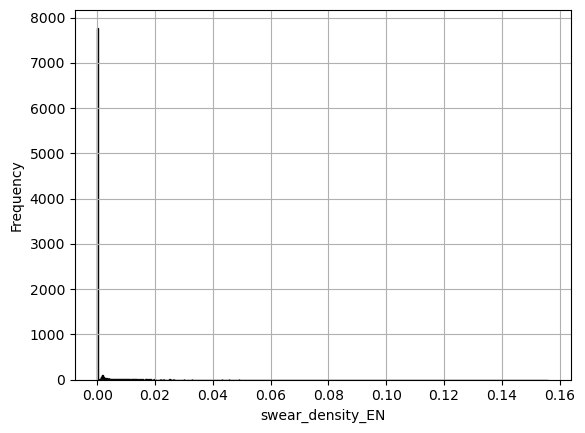

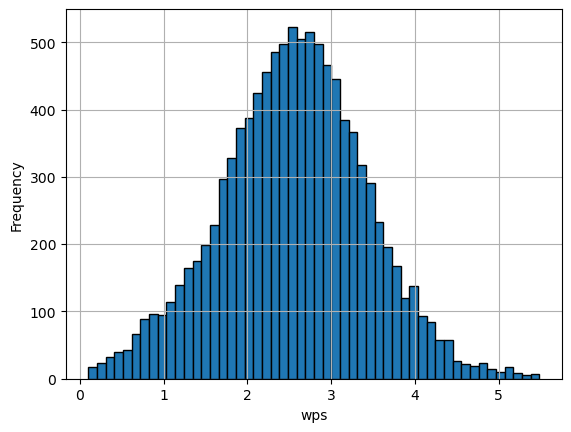

In [44]:
for col in lyrical_cols:
    plot_hist(tracks, col)

In [45]:
tracks = tracks[tracks["avg_token_per_clause"] <= 30]
tracks = tracks[tracks["n_tokens"] <= 1250]
tracks = tracks[tracks["tokens_per_sent"] <=18]

In [46]:
for col in ["lexical_density", "char_per_tok", "avg_token_per_clause", "tokens_per_sent"]:
    print(f"Processing column: {col}, current rows = {len(tracks)}")

    Q1 = tracks[col].quantile(0.15)
    Q3 = tracks[col].quantile(0.85)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    if col == 'year':
        lower = 1980
        upper = 2030

    mask = tracks[col].notna() & ~tracks[col].between(lower, upper)
    n_outliers = mask.sum()
    print(f"Found {n_outliers} outliers")

    # replace outliers with nan
    tracks.loc[mask, col] = np.nan
       
print("Cleaned successfully")

Processing column: lexical_density, current rows = 10213
Found 55 outliers
Processing column: char_per_tok, current rows = 10213
Found 63 outliers
Processing column: avg_token_per_clause, current rows = 10213
Found 201 outliers
Processing column: tokens_per_sent, current rows = 10213
Found 29 outliers
Cleaned successfully


In [47]:
len(tracks)

10213

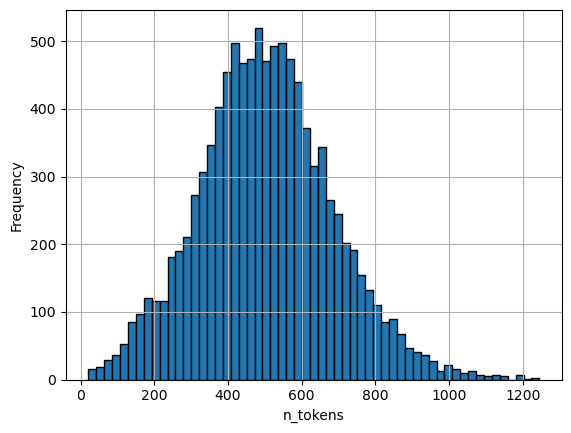

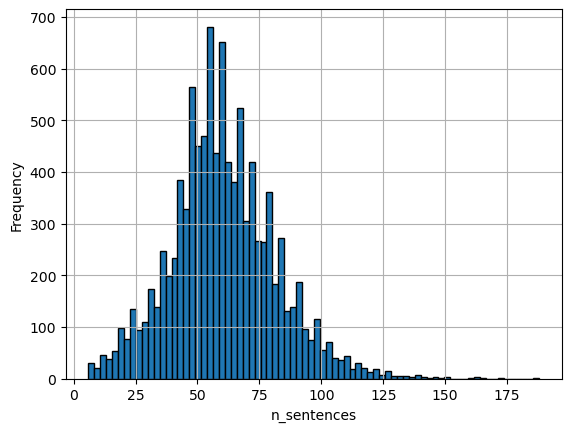

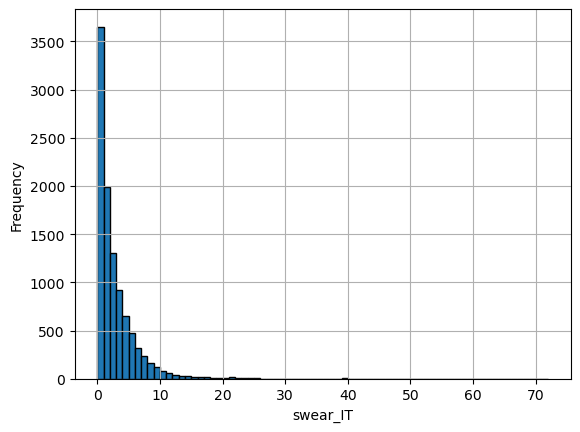

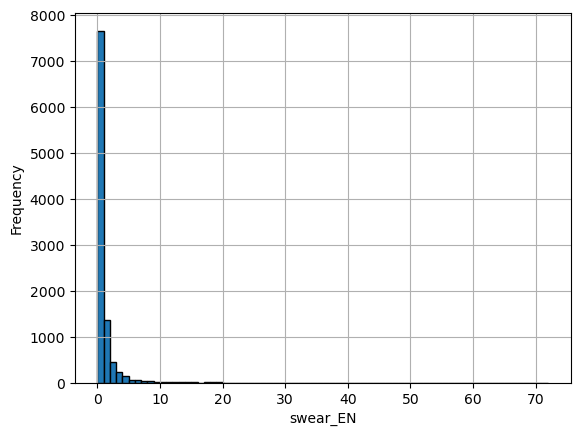

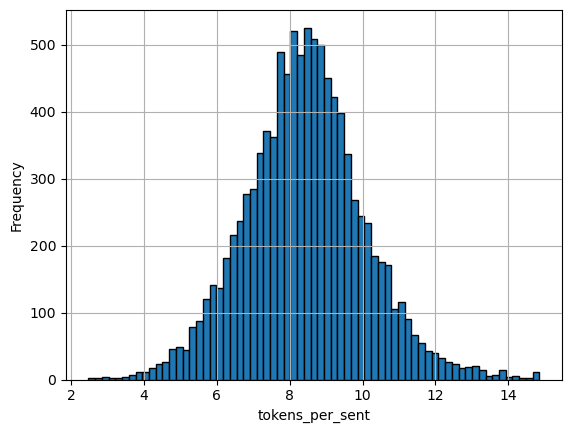

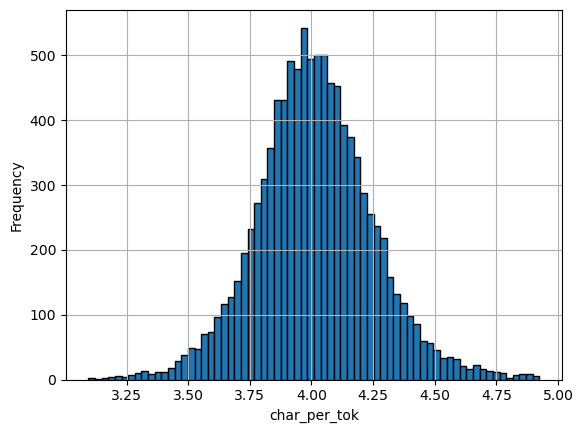

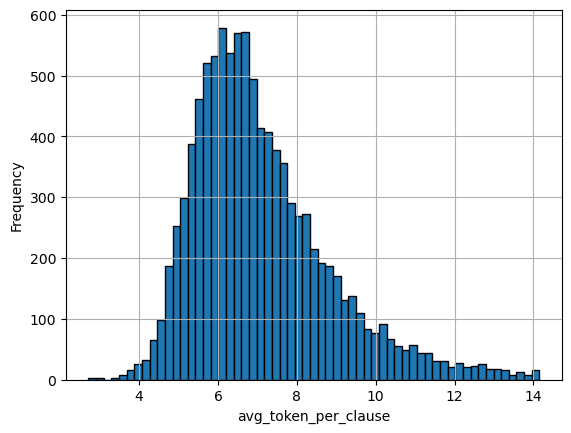

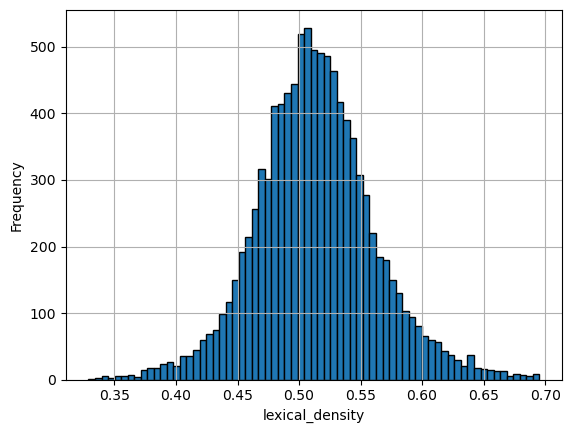

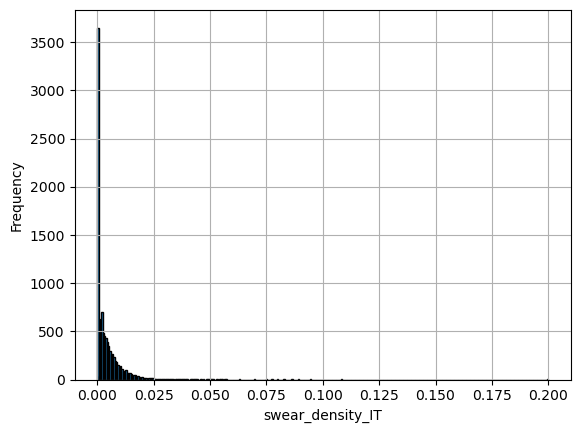

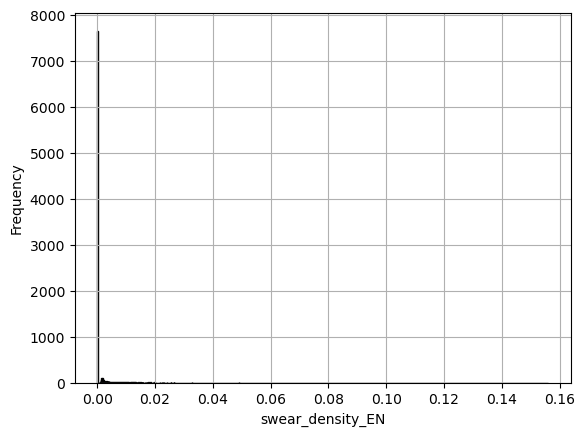

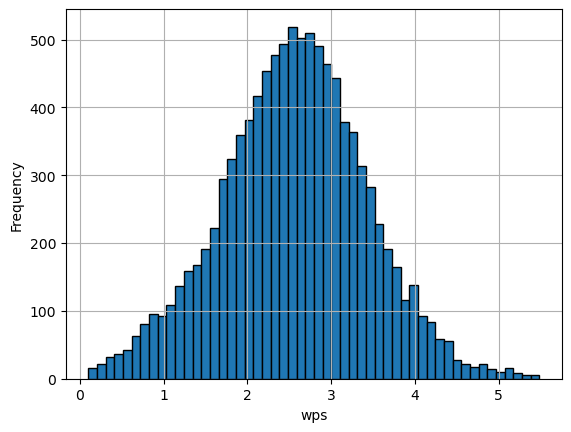

In [48]:
for col in lyrical_cols:
    plot_hist(tracks, col)

## Wrong languages

In [49]:
tracks_lang = tracks.groupby("language")
tracks_lang_stats = tracks_lang.agg(
    n_tracks=("language", "count")
)

display(tracks_lang_stats)


,n_tracks
language,
aa,1
ca,4
co,42
cs,11
cy,1
da,15
de,2
en,709
eo,2


In [50]:
from langdetect import detect_langs
import re

def clean_lyrics(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

tracks["lyrics_clean"] = tracks["lyrics"].fillna("").apply(clean_lyrics)

def detect_langdetect(text: str):
    if len(text) < 20:
        return ("und", 0.0)
    try:
        langs = detect_langs(text)
        # returns list like [en:0.999, ...]
        best = langs[0]
        return (best.lang, float(best.prob))
    except:
        return ("und", 0.0)

pred = tracks["lyrics_clean"].fillna("").apply(detect_langdetect)
tracks["lang_pred"] = pred.apply(lambda x: x[0])
tracks["lang_conf"] = pred.apply(lambda x: x[1])


In [51]:
tracks_lang_pred = tracks.groupby("lang_pred")
tracks_lang_pred_stats = tracks_lang_pred.agg(
    n_tracks=("lang_pred", "count")
)

display(tracks_lang_pred_stats)

,n_tracks
lang_pred,
de,1
en,127
es,43
fr,9
id,2
it,10020
no,1
pt,4
ro,2


In [52]:
display(tracks[["language", "lang_pred", "lang_conf"]])

tracks_wrong_lang = tracks[tracks["language"] != tracks["lang_pred"]].sort_values(by="lang_conf")[["title", "name_artist", "lyrics_clean", "language", "lang_pred"]]
display(tracks_wrong_lang)

,language,lang_pred,lang_conf
0,pl,it,0.999998
1,en,it,0.999995
2,en,it,0.999997
3,it,it,0.999999
4,en,it,0.999996
...,...,...,...
11161,it,it,0.999997
11162,it,it,0.999997
11163,it,it,0.999994
11164,it,it,0.999994


,title,name_artist,lyrics_clean,language,lang_pred
26,Ok ok pih roh toh toh !,Rosa Chemical,"Greg Willen non dormire Pih, pih, pih, pih, pi...",pl,it
262,Blunt*,thasup,"Oh-oh-oh Yeah, yeah-eh Fumo, fumo, fumo, fumo ...",it,so
5076,COURMAYEUR,M¥SS KETA,Tutto l'anno a Courmayeur Sto sognando Courmay...,it,en
9170,Lato oscuro,Colle Der Fomento,"Colle der Fome', Colle der Fome', Colle der Fo...",it,fr
9283,So Free,Grido,I wanna get high I wanna get high I wanna get ...,pl,it
...,...,...,...,...,...
8952,Plug,Rancore,Now to all the brotha's in the place That don'...,en,it
4007,Mea culpa (Demo),Caparezza,(Ah yeah) Caparezza on the microphone Nel futu...,en,it
8597,PARADISO VS. INFERNO (INTERLUDE),Rkomi,Scrivo bene solo ciò che non scrivo Canzoni fa...,pl,it
872,Parte di me,Guè,Yeah-yeah-yeah Yeah-yeah-yeah Yeah-yeah-yeah E...,pl,it


#### Grouping by artist

In [53]:
artist_groups = tracks.groupby("id_artist")
artist_stats = artist_groups.agg(
    popularity_mean=("popularity", "mean"),
    pageviews_mean=("stats_pageviews", "mean"),
    duration_ms_mean=("duration_ms", "mean"),
    n_tracks=("name_artist", "count")
)

artists = artists.merge(artist_stats, left_on='id_author', right_on='id_artist', how='left')
artists = artists[artists['n_tracks'].fillna(0) > 0] # drop artists with no tracks

Let's print top 10 artists and a plot for artist avg popoularity and avg stats_pageviews 

In [54]:
artists.sort_values(by='popularity_mean', ascending=False).head(10)[['name', 'popularity_mean']]

,name,popularity_mean
11,bushwaka,57.500000
88,sfera ebbasta,55.480315
38,geolier,55.099010
98,tony effe,53.575000
3,anna pepe,53.358974
96,thasup,51.010753
95,tedua,48.372093
76,papa v,48.306122
14,capo plaza,47.889908
91,shiva,47.727273


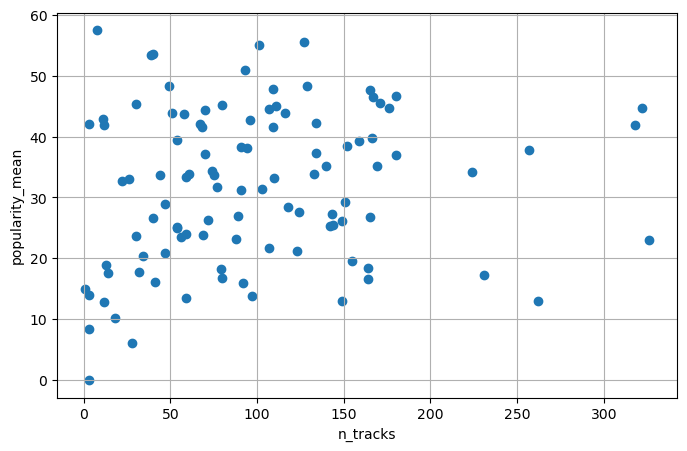

r = 0.158, p = 1.111e-01


In [55]:
plot_xy(artists, 'n_tracks', 'popularity_mean')
[r, p] = calc_pearson(artists, "n_tracks", "popularity_mean")
print(f"r = {r:.3f}, p = {p:.3e}")

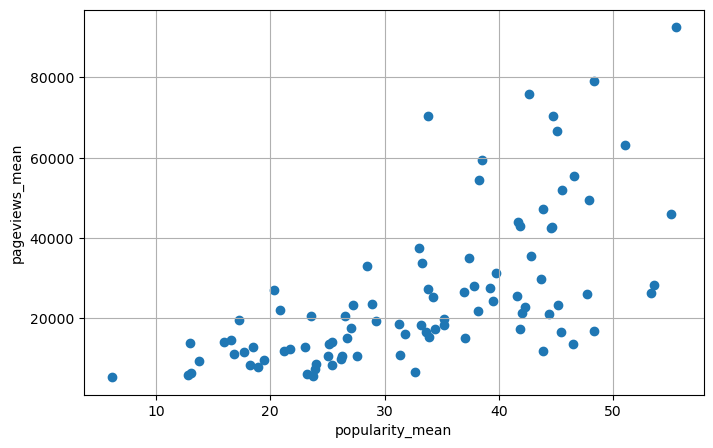

In [56]:
plot_xy(artists, 'popularity_mean', 'pageviews_mean')

In [57]:
[r, p] = calc_pearson(artists, "pageviews_mean", "popularity_mean")
print(f"r = {r:.3f}, p = {p:.3e}")

r = 0.640, p = 5.107e-12


There seems to be an higher correlation between the two features when we take the mean. Maybe popularity is computed taking into account an inertia factor based on the artist's popularity?

In [58]:
artists["pageviews_mean_log"] = np.log(1 + artists["pageviews_mean"])
[r, p] = calc_pearson(artists, "pageviews_mean_log", "popularity_mean")
print(f"r = {r:.3f}, p = {p:.3e}")

r = 0.717, p = 5.997e-16


Even better!

#### Popularity wrt the artist

In [59]:
tracks['pop_rel_artist'] = (tracks['popularity'] - tracks.groupby('id_artist')['popularity'].transform('mean')) / tracks.groupby('id_artist')['popularity'].transform('std')
tracks['stats_pageviews_rel_artist'] = tracks['stats_pageviews'] / tracks.groupby('id_artist')['stats_pageviews'].transform('mean')

[r, p] = calc_pearson(tracks, "stats_pageviews_rel_artist", "pop_rel_artist")
print(f"r = {r:.3f}, p = {p:.3e}")

r = 0.292, p = 8.747e-90


Basically the same obtained on original stats_pageviews and popularity.

#### Audio features of artists

In [60]:
for col in audio_cols:
    tracks[f'{col}_rel_artist'] = tracks[col] / tracks.groupby('id_artist')[col].transform('mean')


#### Variance of audio features for artists

In [61]:
def compute_audio_variance(group):
    return pd.Series({
        f'var_{col}': group[col].var(ddof=1)
        for col in audio_cols
    })

audio_var = tracks.groupby('id_artist').apply(compute_audio_variance).reset_index()

artists = artists.merge(audio_var, left_on='id_author', right_on='id_artist', how='left')
artists = artists.drop(columns=["id_artist"])


/tmp/ipykernel_18484/2495754745.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  audio_var = tracks.groupby('id_artist').apply(compute_audio_variance).reset_index()


In [62]:
tmp = artists[ ['name', 'n_tracks'] + [f'var_{col}' for col in audio_cols] ]
display(tmp.sort_values("var_bpm"))

,name,n_tracks,var_bpm,var_centroid,var_rolloff,var_flux,var_zcr,var_flatness,var_spectral_complexity,var_pitch,var_loudness
62,miss simpatia,3.0,24.306433,0.000370,1.309748e+06,0.012917,0.000612,0.008762,96.464889,227562.719443,33.347207
43,hindaco,3.0,53.763433,0.000476,4.579895e+05,0.003003,0.000395,0.003740,78.595364,481980.950539,260.395752
49,joey funboy,3.0,137.884133,0.000332,2.249503e+05,0.020374,0.000229,0.000127,58.285387,8156.051585,118.754932
9,bigmama,30.0,257.200708,0.000499,3.010150e+05,0.020094,0.000265,0.003121,38.299280,164641.909070,46.284250
23,dark polo gang,134.0,266.045550,0.000540,2.916232e+05,0.008971,0.000272,0.002203,46.916542,138814.531739,72.226810
...,...,...,...,...,...,...,...,...,...,...,...
24,doll kill,28.0,970.112255,0.001045,6.520407e+05,0.015805,0.000612,0.005992,51.536660,214659.046894,36.307360
73,noyz narcos,159.0,1001.402400,0.000650,3.064714e+05,0.010053,0.000285,0.003846,57.524123,111643.029436,57.409941
47,jack the smoker,107.0,1013.506013,0.000756,3.244913e+05,0.013105,0.000326,0.002775,48.044262,120310.775774,56.234066
64,mistico,3.0,1762.162033,0.000360,3.458648e+05,0.009363,0.000299,0.000469,3.974363,406153.265151,36.228603


In [63]:
audio_var_year = tracks.groupby(['id_artist', 'year']).apply(compute_audio_variance).reset_index()

var_cols = [f'var_{col}' for col in audio_cols]
agg_dict = {col: ('mean') for col in var_cols}

audio_var_group = audio_var_year.groupby('id_artist').agg(agg_dict).reset_index()
audio_var_group = audio_var_group.rename(columns={col: f'{col}_mean' for col in var_cols})

for col in audio_cols:
    tmp1 = audio_var_group[f"var_{col}_mean"].mean() 
    tmp2 = artists[f"var_{col}"].mean()
    print(f"{col}: {tmp1:.6f}, {tmp2:.6f}")


bpm: 584.832124, 623.330369
centroid: 0.000512, 0.000627
rolloff: 222638.559234, 275622.453198
flux: 0.010995, 0.013519
zcr: 0.000219, 0.000266
flatness: 0.002250, 0.002647
spectral_complexity: 43.322225, 54.167188
pitch: 107166.856729, 123249.619006
loudness: 49.985226, 59.914694


/tmp/ipykernel_18484/243715666.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  audio_var_year = tracks.groupby(['id_artist', 'year']).apply(compute_audio_variance).reset_index()


Indeed, this suggests, as expected, that artists are locally (wrt time) constant with their musical features and genre, but show signs of change over a longer period of time.

#### Popularity wrt the region

In [64]:
merged = tracks.merge(artists[['id_author', 'region']], left_on='id_artist', right_on='id_author')
tracks['pop_rel_region'] = (merged['stats_pageviews'] - merged.groupby('region')['stats_pageviews'].transform('mean')) / merged.groupby('region')['stats_pageviews'].transform('std')

In [65]:
artists.groupby("region").count()

,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,province,country,latitude,longitude,popularity_mean,pageviews_mean,duration_ms_mean,n_tracks,pageviews_mean_log,var_bpm,var_centroid,var_rolloff,var_flux,var_zcr,var_flatness,var_spectral_complexity,var_pitch,var_loudness
region,,,,,,,,,,,,,,,,,,,,,,,,,,
Calabria,1,1,1,1,1,1,1,0,1,1,1,1,1,0,1,1,0,1,1,1,1,1,1,1,1,1
Campania,10,10,10,10,10,10,10,5,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
Emilia-Romagna,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Lazio,8,8,8,8,8,8,8,7,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
Liguria,3,3,3,3,3,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
Lombardia,24,24,24,24,24,23,24,15,24,24,24,24,24,23,24,24,23,24,24,24,24,24,24,24,24,24
Marche,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Piemonte,5,5,5,5,5,5,5,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
Puglia,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


Average popularity for region and top regions:

In [66]:
tracks_with_region = tracks.merge(artists[['id_author', 'region']], left_on='id_artist', right_on='id_author', how='left')

avg_pop_region = tracks_with_region.groupby('region')['popularity'].mean().sort_values(ascending=False)

print(avg_pop_region.head(10))

region
Sicilia           44.767045
Puglia            39.188679
Emilia-Romagna    38.191489
Campania          38.108243
Liguria           37.637255
Lazio             36.645161
Veneto            36.087481
Lombardia         33.073757
Piemonte          29.415638
Sardegna          26.309572
Name: popularity, dtype: float64


However this is not very informative! The amount of artists for each region is often low.

In [67]:
artists[artists["region"] == "Sicilia"].sort_values(by='popularity_mean', ascending=False).head(10)[['name', 'popularity_mean']]

,name,popularity_mean
58,marracash,44.767045


In [68]:
artists[artists["region"] == "Puglia"].sort_values(by='popularity_mean', ascending=False).head(10)[['name', 'popularity_mean']]

,name,popularity_mean
13,caparezza,39.789157
55,madman,38.532895


In [69]:
artists[artists["region"] == "Emilia-Romagna"].sort_values(by='popularity_mean', ascending=False).head(10)[['name', 'popularity_mean']]

,name,popularity_mean
26,drefgold,38.191489


## Dataset artists stats by year

In [70]:
df = tracks.merge(artists[['id_author', 'name', 'region']], 
                  left_on='id_artist', right_on='id_author', how='left')
df = df.drop(columns="id_artist")

artist_year = (
    df.groupby(['id_author', 'year'])
      .agg(
          n_tracks=('id', 'count'),
          popularity_mean=('popularity', 'mean'),
          popularity_std=('popularity', 'std'),
          pageviews_sum=('stats_pageviews', 'sum'),
          bpm_mean=('bpm', 'mean'),
          rms_mean=('rms', 'mean'),
          flux_mean=('flux', 'mean'),
          zcr_mean=('zcr', 'mean'),
          swear_IT_mean=('swear_IT', 'mean'),
          swear_density_mean=('swear_density_IT', 'mean'),
          lexical_density_mean=('lexical_density', 'mean'),
          duration_mean=('duration_ms', 'mean'),
          explicit_ratio=('explicit', 'mean')  
      )
      .reset_index()
)


In [71]:
growth_data = []

for artist_id, grp in artist_year.groupby('id_author'):
    grp = grp.dropna(subset=['popularity_mean', 'year'])
    if grp['year'].nunique() > 1:
        X = grp['year'].values.reshape(-1, 1)
        y = grp['popularity_mean'].values
        model = LinearRegression().fit(X, y)
        slope = model.coef_[0]
    else:
        slope = np.nan
    growth_data.append((artist_id, slope))

growth_df = pd.DataFrame(growth_data, columns=['id_artist', 'growth_index'])

artists = artists.merge(growth_df, left_on='id_author', right_on='id_artist', how='left')
artists = artists.drop(columns=['id_artist'])

### Pairwise correlations

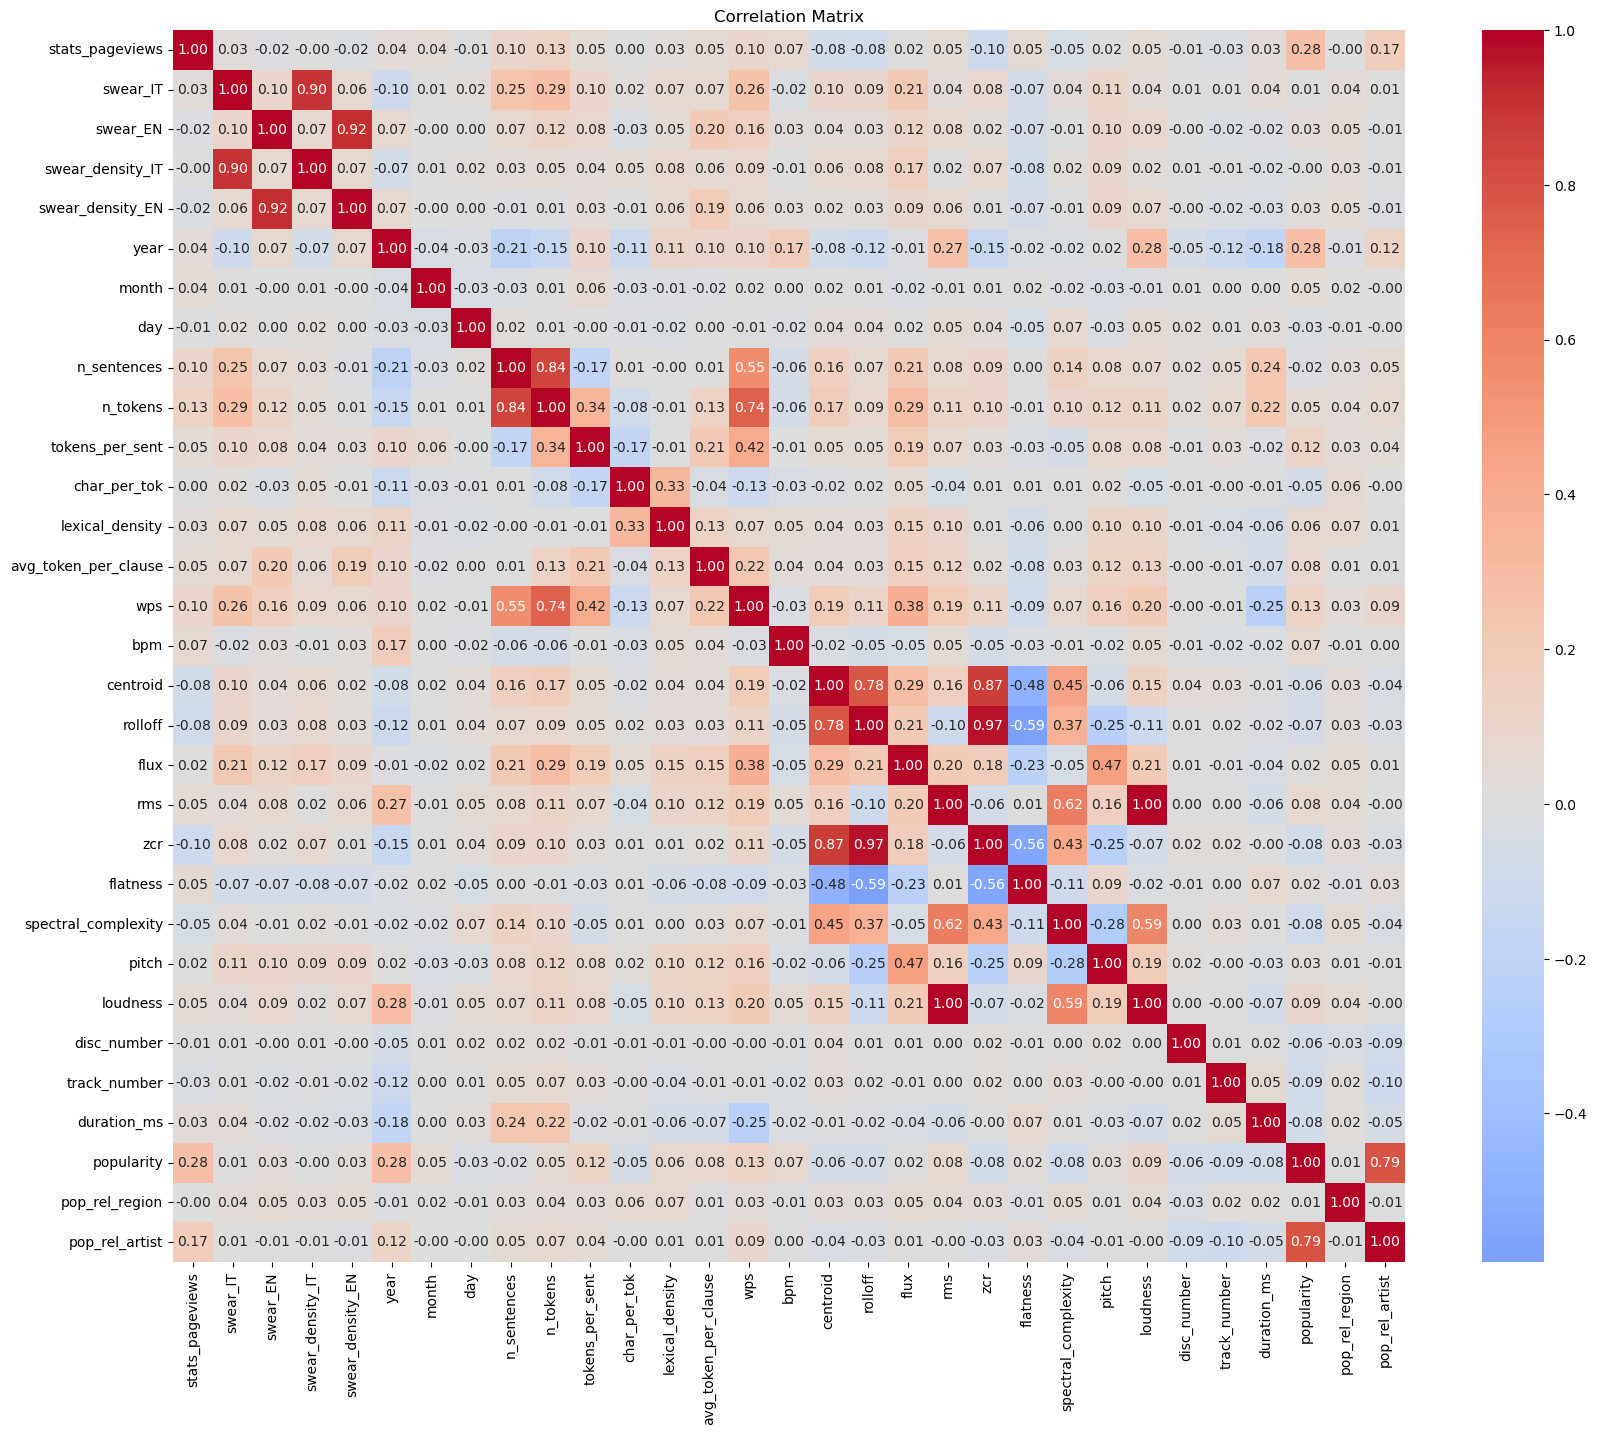

In [72]:
num_cols = ['stats_pageviews',
            'swear_IT',
            'swear_EN',
            'swear_density_IT',
            'swear_density_EN',
            'year',
            'month',
            'day',
            'n_sentences',
            'n_tokens',
            'tokens_per_sent',
            'char_per_tok',
            'lexical_density',
            'avg_token_per_clause',
            'wps',
            'bpm',
            'centroid',
            'rolloff',
            'flux',
            'rms',
            'zcr',
            'flatness',
            'spectral_complexity',
            'pitch',
            'loudness',
            'disc_number',
            'track_number',
            'duration_ms',
            'popularity',
            'pop_rel_region', 
            'pop_rel_artist'] 
corr = tracks.filter(num_cols).corr()

plt.figure(figsize=(20,16))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix")
plt.show()

In [73]:
#tracks = tracks.drop(columns=['rms']) # for now keep zcr/rolloff, rms is equal to loudness
#audio_cols.remove('rms')
#clust_cols.remove('rms')

In [74]:
[r, p] = calc_pearson(tracks, "popularity", "loudness")
print(f"r = {r:.3f}, p = {p:.3e}")

[r, p] = calc_pearson(tracks, "popularity", "stats_pageviews")
print(f"r = {r:.3f}, p = {p:.3e}")

tracks["stats_pageviews_log"] = np.log(1 + tracks["stats_pageviews"])
[r, p] = calc_pearson(tracks, "popularity", "stats_pageviews_log")
print(f"r = {r:.3f}, p = {p:.3e}")


r = 0.088, p = 5.054e-19
r = 0.279, p = 7.877e-82
r = 0.385, p = 1.038e-160


Conclusions:

- Popularity has a moderate correlation with the number of views (which makes sense). However, we expect some even higher correlation. In fact, the two columns have different distributions (one is normalized in the range $[0, 100]$, the other is unbounded). The two columns become much more correlated if we calculate the logarithm of the number of views.
- It can be shown that normalizing the year with an axis scaling (e.g., $[1992, 2025] \rightarrow [1, 34]$) has no effect on the correlation.

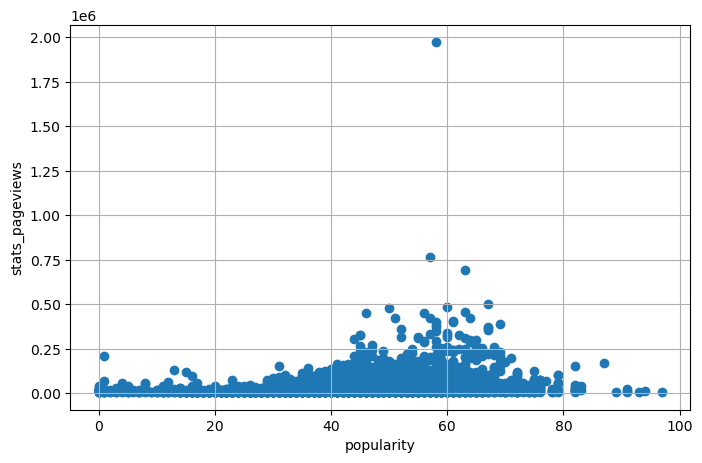

In [75]:
plot_xy(tracks, "popularity", "stats_pageviews")

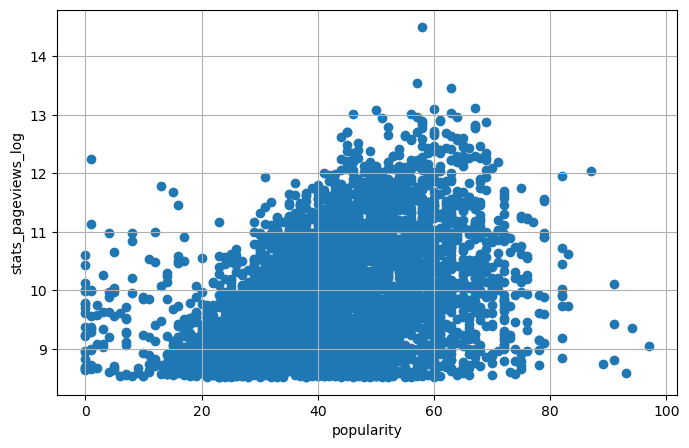

In [76]:
plot_xy(tracks, "popularity", "stats_pageviews_log")

There are a lot of data points with high popularity and low page views, and vice versa. I'm wondering how popularity is actually computed.

### Partial correlation

`year` is positively correlated with both `loudness` and `popularity`; loudness and popularity are also correlated (with a lower coefficient). Is there a solid way to determine whether the correlation between loudness and popularity is caused by the year?

Let's calculate the partial correlation between loudness and popularity (removing the linear dependence from year, before computing the correlation).

In [77]:
import statsmodels.api as sm

tmp = tracks[['loudness','popularity','year']].dropna()
X = sm.add_constant(tmp[['loudness','year']])
res = sm.OLS(tmp['popularity'], X).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     451.6
Date:                Mon, 05 Jan 2026   Prob (F-statistic):          1.21e-188
Time:                        20:02:18   Log-Likelihood:                -44361.
No. Observations:               10213   AIC:                         8.873e+04
Df Residuals:                   10210   BIC:                         8.875e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1588.6262     56.567    -28.084      0.0

It seems that loudness and popularity are not correlated anymore (the $p$-value is $0.404 > 0.05$).

### Popularity in time

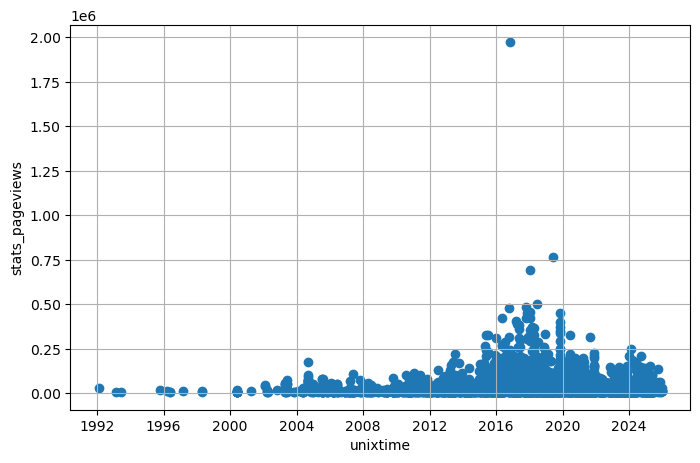

In [78]:
plot_xy(tracks, 'unixtime', 'stats_pageviews')

In [79]:
for artist, group in artist_groups:
    print(f"Artist: {artist}, num_tracks={len(group)}")
    group_sorted = group.sort_values("unixtime")
    # display(group_sorted.filter(["unixtime"]))
    

Artist: ART02449272, num_tracks=13
Artist: ART02666525, num_tracks=30
Artist: ART02733420, num_tracks=176
Artist: ART03111237, num_tracks=34
Artist: ART04141409, num_tracks=318
Artist: ART04205421, num_tracks=59
Artist: ART05528539, num_tracks=107
Artist: ART07024718, num_tracks=169
Artist: ART07127070, num_tracks=159
Artist: ART07469279, num_tracks=79
Artist: ART07629990, num_tracks=149
Artist: ART08177154, num_tracks=109
Artist: ART08302616, num_tracks=80
Artist: ART08456301, num_tracks=118
Artist: ART09119396, num_tracks=94
Artist: ART12092805, num_tracks=49
Artist: ART14073567, num_tracks=12
Artist: ART14383873, num_tracks=56
Artist: ART15560128, num_tracks=262
Artist: ART16868977, num_tracks=58
Artist: ART17240256, num_tracks=133
Artist: ART17812958, num_tracks=143
Artist: ART18853907, num_tracks=70
Artist: ART19060721, num_tracks=30
Artist: ART19605256, num_tracks=54
Artist: ART19729064, num_tracks=88
Artist: ART20729624, num_tracks=54
Artist: ART22979236, num_tracks=54
Artist: A

Is rap becoming more popular?

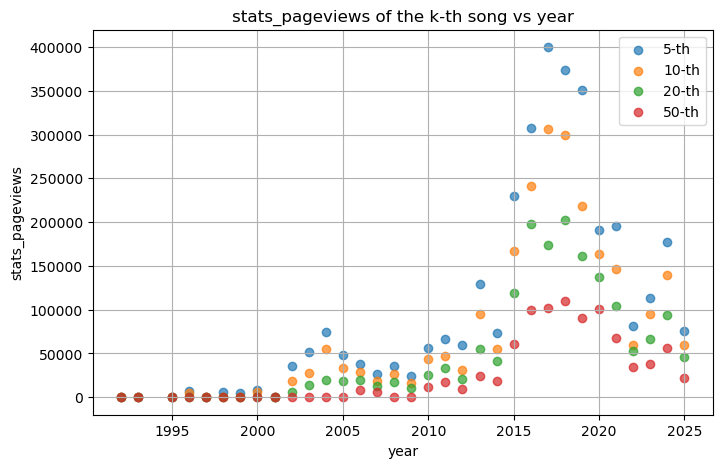

In [80]:
def plot_topk(df, col1, col2, Ks):
    df = df.dropna(subset=[col2])
    plt.figure(figsize=(8,5))
    
    for K in Ks:
        topk = (df.sort_values([col1, col2], ascending=[True, False])
                  .groupby(col1).head(K))
        cov_topk = topk.groupby(col1)
        group_sizes = topk.groupby("year").size()
        cov_topk = topk.groupby(col1)[col2].last().reset_index()
        cov_topk[col2] = cov_topk.apply(
            lambda row: 0 if group_sizes[row["year"]] < K else row[col2],
            axis=1
        )
        plt.scatter(cov_topk[col1], cov_topk[col2], label=f"{K}-th", alpha=0.7)
    
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.grid(True)
    plt.legend()
    plt.title(f"{col2} of the k-th song vs {col1}")
    plt.show()

Ks = [5, 10, 20, 50]
plot_topk(tracks, "year", "stats_pageviews", Ks)

The peak of pageviews from 2015 onward is actually consistent with the advent of trap music.

,year,n_tracks
0,1975.0,1
1,1977.0,1
2,1981.0,1
3,1986.0,2
4,1992.0,7
5,1993.0,32
6,1994.0,22
7,1995.0,8
8,1996.0,68
9,1997.0,20


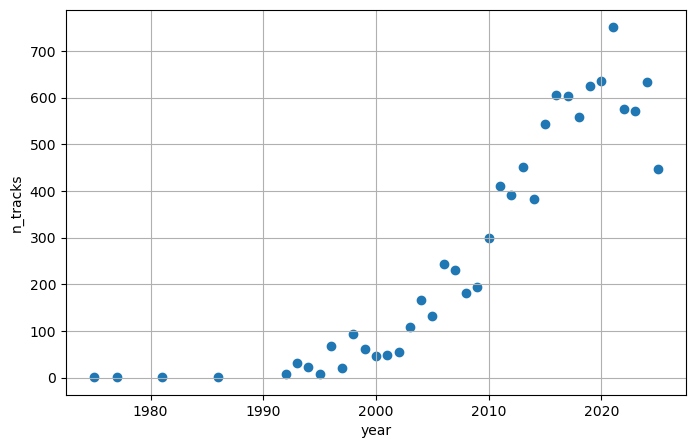

In [81]:
year_groups = tracks.groupby("year")

year_stats = year_groups.agg(
    n_tracks=("year", "count")
).reset_index()

display(year_stats)

plot_xy(year_stats, 'year', 'n_tracks')

## Map of artists popularity (also in time)

In [82]:
fig = px.scatter_geo(
    artists, lat='latitude', lon='longitude',
    color='popularity_mean', size='n_tracks',
    hover_name='name',
    hover_data={'popularity_mean': ':.2f', 'n_tracks': True, 'latitude': False, 'longitude': False},
    color_continuous_scale='Viridis',
    projection='natural earth',
    title='Mean Track Popularity by Artist Location'
)
fig.update_traces(marker=dict(opacity=0.8))
fig.write_html("map_popularity.html")

In [83]:
artist_loc = artists[['id_author', 'name', 'latitude', 'longitude']].copy()

agg = artist_year.merge(artist_loc, left_on='id_author', right_on='id_author', how='left')

agg = agg.dropna(subset=['latitude', 'longitude', 'year'])

agg['year'] = agg['year'].astype(int)

agg['popularity_mean'] = agg['popularity_mean'].fillna(0)
agg['pageviews_sum'] = agg['pageviews_sum'].fillna(0)
agg['n_tracks'] = agg['n_tracks'].fillna(0).astype(int)

agg['size_scaled'] = 4*np.sqrt(agg['n_tracks']) 

agg = agg.sort_values('year')
years_order = sorted(agg['year'].unique())

fig = px.scatter_geo(
    agg,
    lat='latitude',
    lon='longitude',
    color='popularity_mean',
    size='size_scaled',
    hover_name='name',
    hover_data={
        'popularity_mean': ':.2f',
        'pageviews_sum': True,
        'n_tracks': True,
        'latitude': False,
        'longitude': False
    },
    animation_frame='year',
    color_continuous_scale='Viridis',
    projection='natural earth',
    title='Artist popularity by location — year by year'
)

fig.update_traces(marker=dict(opacity=0.8))
fig.update_layout(legend_title_text='Popularity', coloraxis_colorbar=dict(title='popularity'))
fig.write_html("map_popularity_by_year.html")

## Principal Component Analysis
Let's do a PCA of the audio features and lyrical features.

Dimensionality reduction on audio+lyrical features ( 9906 ):  0.35
20  ->  13
Dimensionality reduction on audio features ( 9954 ):  0.3333333333333333
9  ->  6
Dimensionality reduction on clustering features ( 9954 ):  0.2857142857142857
14  ->  10


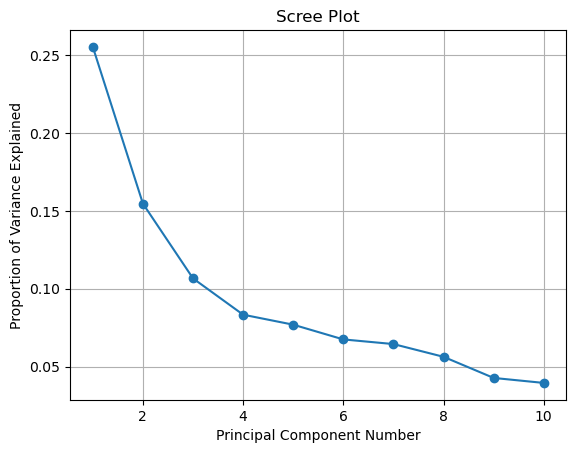

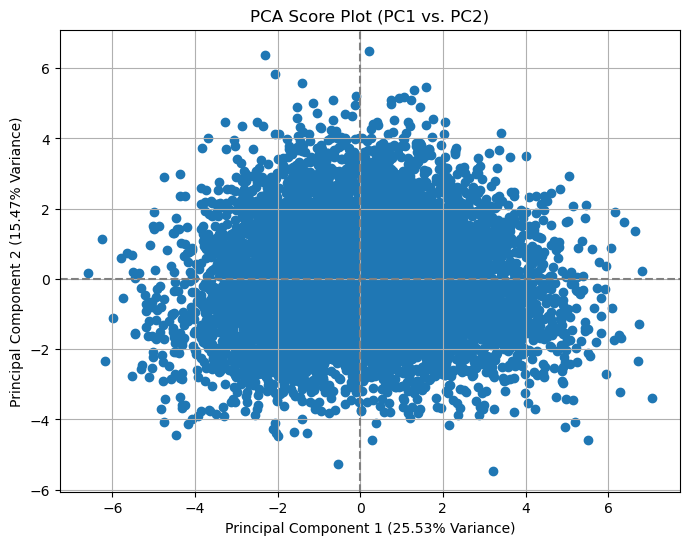

In [84]:
cols = audio_cols + lyrical_cols

tracks = tracks.dropna(subset=clust_cols)

X = tracks[cols]
X = X.dropna()
scaler = StandardScaler()
X = scaler.fit_transform(X)
pca = PCA(n_components = 0.95)
pca.fit(X)
pca_audio_lyrical = pca.transform(X)
print("Dimensionality reduction on audio+lyrical features (", len(X), "): ", (len(cols) - pca.n_components_)/len(cols))
print(len(cols), " -> ", pca.n_components_)

X_audio_df = tracks[audio_cols]
X_audio = scaler.fit_transform(X_audio_df)
pca = PCA(n_components = 0.95)
pca.fit(X_audio)
pca_audio = pca.transform(X_audio)
print("Dimensionality reduction on audio features (", len(X_audio), "): ", (len(audio_cols) - pca.n_components_)/len(audio_cols))
print(len(audio_cols), " -> ", pca.n_components_)

X_clust_df = tracks[clust_cols]
X_clust = scaler.fit_transform(X_clust_df)
pca = PCA(n_components = 0.92)
pca.fit(X_clust)
pca_clust = pca.transform(X_clust)
print("Dimensionality reduction on clustering features (", len(X_clust), "): ", (len(clust_cols) - pca.n_components_)/len(clust_cols))
print(len(clust_cols), " -> ", pca.n_components_)


plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component Number')
plt.ylabel('Proportion of Variance Explained')
plt.grid(True)
plt.show()

scores = pca.transform(X_clust)
plt.figure(figsize=(8, 6))
plt.scatter(scores[:, 0], scores[:, 1])
plt.title('PCA Score Plot (PC1 vs. PC2)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.show()

In [85]:
import pickle

pca_clust_cols = [f"pc_clust_{i+1}" for i in range(pca_clust.shape[1])]
pickle.dump(pca_clust_cols, open("tmp/pca_clust_cols.pkl", "wb"))
pca_clust_df = pd.DataFrame(pca_clust, columns=pca_clust_cols, index=X_clust_df.index)
tracks = pd.concat([tracks, pca_clust_df], axis = 1)

pca_audio_cols = [f"pc_audio_{i+1}" for i in range(pca_audio.shape[1])]
pickle.dump(pca_audio_cols, open("tmp/pca_audio_cols.pkl", "wb"))
pca_audio_df = pd.DataFrame(pca_audio, columns=pca_audio_cols, index=X_audio_df.index)
tracks = pd.concat([tracks, pca_audio_df], axis = 1)

tracks = tracks.merge(
        artists[['id_author', 'region']], 
        left_on='id_artist', 
        right_on='id_author', 
        how='left'
    )

In [86]:
artists.to_parquet("tmp/p01_artists.parquet")
tracks.to_parquet("tmp/p01_tracks.parquet")
artist_year.to_parquet("tmp/p01_artists_year.parquet")

## UMAP

2026-01-05 20:02:38.307826: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-05 20:02:43.092238: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-05 20:02:52.134318: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/hush/.local/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



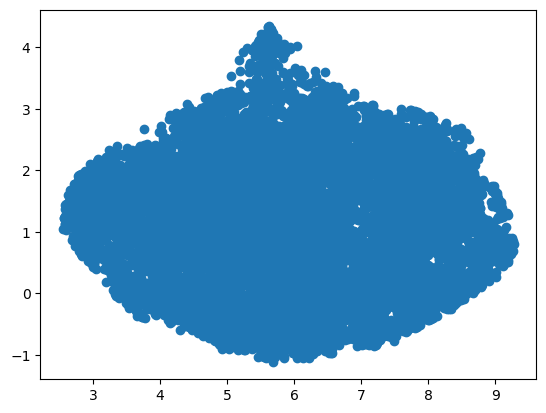

In [87]:
import umap

umap_model = umap.UMAP(n_components=3, random_state=12)
X_umap3 = umap_model.fit_transform(X_clust) 
X_umap3 = pd.DataFrame(X_umap3, columns=cols_umap3, index=X_clust_df.index)
X_umap3.to_parquet("tmp/X_umap3.parquet")

plt.scatter(X_umap3["umap3_1"], X_umap3["umap3_2"])
plt.show()

/home/hush/.local/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



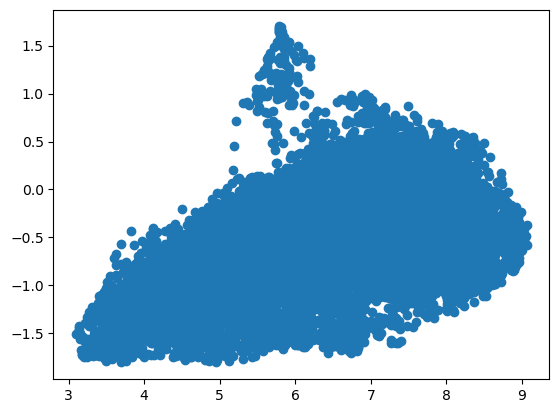

In [88]:
umap_model = umap.UMAP(n_components=5, random_state=12)
X_umap5 = umap_model.fit_transform(X_clust) 
X_umap5 = pd.DataFrame(X_umap5, columns=cols_umap5, index=X_clust_df.index)
X_umap5.to_parquet("tmp/X_umap5.parquet")

plt.scatter(X_umap5["umap5_1"], X_umap5["umap5_2"])
plt.show()

/home/hush/.local/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



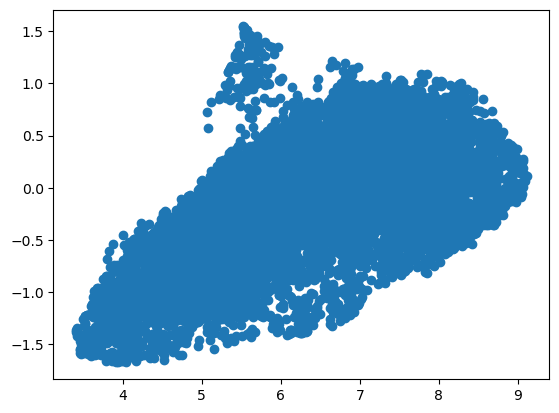

In [89]:
umap_model = umap.UMAP(n_components=8, random_state=12)
X_umap8 = umap_model.fit_transform(X_clust) 
X_umap8 = pd.DataFrame(X_umap8, columns=cols_umap8, index=X_clust_df.index)
X_umap8.to_parquet("tmp/X_umap8.parquet")

plt.scatter(X_umap8["umap8_1"], X_umap8["umap8_2"])
plt.show()

## T-SNE

In [90]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne2 = tsne.fit_transform(X_clust)
X_tsne2 = pd.DataFrame(X_tsne2, columns=["tsne2_1", "tsne2_2"], index=X_clust_df.index)
X_tsne2.to_parquet("tmp/X_tsne2.parquet")

tsne = TSNE(n_components=3, perplexity=30, learning_rate=200, random_state=42)
X_tsne3 = tsne.fit_transform(X_clust)
X_tsne3 = pd.DataFrame(X_tsne3, columns=["tsne3_1", "tsne3_2", "tsne3_3"], index=X_clust_df.index)
X_tsne3.to_parquet("tmp/X_tsne3.parquet")

## Embeddings

In [92]:
from sentence_transformers import SentenceTransformer
import re
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SentenceTransformer('../tmp/BERT-model/paraphrase-multilingual-MiniLM-L12-v2', device=device)

Don't need to run the next cell again, the embeddings are already saved in a parquet in the tmp folder.

In [ ]:
embeddings = model.encode(
    tracks["lyrics_clean"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/156 [00:00<?, ?it/s]

In [ ]:
emb_df = pd.DataFrame(embeddings, index=tracks.index)
emb_cols = [f"lyr_emb_{i}" for i in range(emb_df.shape[1])]
emb_df.columns = emb_cols

# cache embeddings only
emb_df.to_parquet("tmp/p01_lyrics_embeddings.parquet")

# cache tracks + embeddings (row-aligned) for downstream supervised tasks
tracks_emb = pd.concat([tracks.reset_index(drop=True), emb_df.reset_index(drop=True)], axis=1)
tracks_emb.to_parquet("tmp/tracks_with_embeddings.parquet")

pickle.dump(emb_cols, open("tmp/emb_cols.pkl", "wb"))

==============================================================================